# Case SENTINEL — Stage 3: Integrated Evidence Synthesis & Final Escalation
**DECODE X | NLD Synapse 2026 | March 2026**

Pipeline: Reload All Stages → Network Structure → Motif Participation → Counterparty Concentration → Synchronization → Composite Scoring → Final Ranking → 12-Entity Escalation → False Positive Control → Exclusion Log

---

**Stage 3 Mandate**

| Dimension | Source | Weight |
|---|---|---|
| Network Structure | Task-1 Trades (centrality, PageRank, clustering) | 25% |
| Motif Participation | Task-1 + Task-2 (loop count, mechanism severity) | 30% |
| Counterparty Concentration | Task-1 + Task-1-Order (HHI, CP diversity) | 25% |
| Synchronization | Task-2 (60s windows, wash rate, order sync) | 20% |


In [1]:
# ─────────────────────────────────────────────────────────────────────────────
# CELL 1 — Environment setup, library imports, path constants
# ─────────────────────────────────────────────────────────────────────────────
import pandas as pd
import numpy as np
import networkx as nx
import glob
import os
import re
import warnings
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from tqdm.auto import tqdm
from itertools import combinations
from collections import defaultdict

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 80)
pd.set_option('future.no_silent_downcasting', True)
sns.set_theme(style='darkgrid', context='notebook', font='DejaVu Sans')

# ── Paths ─────────────────────────────────────────────────────────────────────
BASE             = r'E:\Synapse-BI\04 – Case SENTINEL'
TRADES_CSV       = os.path.join(BASE, 'master_trades_combined.csv')
SUSPECT_TRD_DIR  = os.path.join(BASE, 'Suspicious list', 'Trades')
SUSPECT_ORD_DIR  = os.path.join(BASE, 'Suspicious list', 'Orders')
VAL_TRADES_DIR   = os.path.join(BASE, 'Validation Set', 'Trades')
VAL_ORDERS_DIR   = os.path.join(BASE, 'Validation Set', 'Orders')
CHARTS_DIR       = r'E:\Synapse-BI\sentinel_charts'
S3_DIR           = r'E:\Synapse-BI\sentinel_orders_charts'
os.makedirs(CHARTS_DIR, exist_ok=True)
os.makedirs(S3_DIR, exist_ok=True)

# ── Constants ─────────────────────────────────────────────────────────────────
LOOP_MIN_VOLUME       = 500
LOOP_MAX_LENGTH       = 3
PUMP_THRESHOLD        = 5.0
SYNC_GAP_SEC          = 60
HFT_TRADES_PER_DAY    = 20
HFT_MIN_COUNTERPARTS  = 8
HFT_LOOP_PERSIST_DAYS = 2
VAL_SCRIPS            = {'554412', '555835', '556114', '556155'}

# Stage 3 composite weight profile  (sum = 1.0)
W3 = {
    'network' : 0.25,    # S_network  — centrality / structural position
    'motif'   : 0.30,    # S_motif    — loop participation + mechanism severity
    'conc'    : 0.25,    # S_conc     — counterparty concentration / wash signals
    'sync'    : 0.20,    # S_sync     — temporal coordination evidence
}

MECHANISM_SEVERITY = {
    'Infrastructure-Linked Pump & Dump': 5,
    'Pump & Dump'                       : 4,
    'Circular Trading'                  : 3,
    'Infrastructure-Linked'             : 2,
    'Legitimate HFT'                    : 0,
    'Ambiguous'                         : 1,
}
TIER_CLR = {'LOW':'#2A9D8F','MEDIUM':'#E9C46A','HIGH':'#F4A261','CRITICAL':'#E63946'}
MONTH_MAP = {
    'jan':'JAN','feb':'FEB','mar':'MAR','apr':'APR','may':'MAY','jun':'JUN',
    'jul':'JUL','july':'JUL','aug':'AUG','sep':'SEP','oct':'OCT','nov':'NOV','dec':'DEC',
}

print('Stage 3 environment initialised.')
print(f'Composite weights : {W3}')


Stage 3 environment initialised.
Composite weights : {'network': 0.25, 'motif': 0.3, 'conc': 0.25, 'sync': 0.2}


## Section 1 — Reload Stage Outputs (Master Trades, Suspects, Validation Data)
Align all entity identifiers across Task-1 (trades), Task-1-Order, and Task-2 (validation).


In [7]:
# ─────────────────────────────────────────────────────────────────────────────
# 1A — Master trade tape (Stage 1 full corpus)
# ─────────────────────────────────────────────────────────────────────────────
df = pd.read_csv(TRADES_CSV, low_memory=False)
if 'Sell Client code' in df.columns:
    df['Sell Client Code'] = df['Sell Client Code'].fillna(df['Sell Client code'])
df.drop(columns=[c for c in ['Sell Client code','Buy Timestamp','Sell Timestamp']
                 if c in df.columns], inplace=True)
for col in ['SCRIP_CODE','Buy Client Code','Sell Client Code',
            'BUY_MEMBER_CODE','SELL_MEMBER_CODE']:
    df[col] = df[col].astype(str).str.strip()
df['TRADE_TIME_DT'] = pd.to_datetime(df['TRADE_TIME'], errors='coerce', format='mixed')

# ─────────────────────────────────────────────────────────────────────────────
# 1B — Stage 1 suspect list (trades)
# ─────────────────────────────────────────────────────────────────────────────
_sus = []
for f in glob.glob(os.path.join(SUSPECT_TRD_DIR, '*.csv')):
    try:
        tmp = pd.read_csv(f)
        if not tmp.empty:
            _sus.append(tmp)
    except Exception:
        pass
suspects_trd = pd.concat(_sus, ignore_index=True)
suspects_trd.columns = suspects_trd.columns.str.strip()
suspects_trd['client_id'] = suspects_trd['client_id'].astype(str).str.strip()
s1_known = set(suspects_trd['client_id'])

# ─────────────────────────────────────────────────────────────────────────────
# 1C — Stage 1 suspect list (orders)
# Actual column name in source files is 'big_ord_client_id' — rename to client_id
# ─────────────────────────────────────────────────────────────────────────────
_suo = []
for f in glob.glob(os.path.join(SUSPECT_ORD_DIR, '*.csv')):
    try:
        tmp = pd.read_csv(f)
        if not tmp.empty:
            _suo.append(tmp)
    except Exception:
        pass
if _suo:
    suspects_ord = pd.concat(_suo, ignore_index=True)
    suspects_ord.columns = suspects_ord.columns.str.strip()
    # Normalise whichever client-id column exists to 'client_id'
    _id_col_candidates = ['client_id', 'big_ord_client_id', 'big_order_client_id',
                          'Client Code', 'client_code', 'ClientId']
    _found = next((c for c in _id_col_candidates if c in suspects_ord.columns), None)
    if _found and _found != 'client_id':
        suspects_ord.rename(columns={_found: 'client_id'}, inplace=True)
    suspects_ord['client_id'] = suspects_ord['client_id'].astype(str).str.strip()
    s1_ord_known = set(suspects_ord['client_id'])
else:
    suspects_ord = pd.DataFrame(columns=['client_id', 'scrip_code'])
    s1_ord_known = set()

# ─────────────────────────────────────────────────────────────────────────────
# 1D — Validation trades (Stage 2 deep-dive)
# ─────────────────────────────────────────────────────────────────────────────
def parse_val_filename(path):
    name = os.path.splitext(os.path.basename(path))[0]
    m    = re.match(r'^(\d+)_(\d+)_([A-Za-z]+)_(\d{4})$', name)
    if m:
        scrip = m.group(1)
        day   = m.group(2).zfill(2)
        mon   = MONTH_MAP.get(m.group(3).lower(), m.group(3)[:3].upper())
        yr    = m.group(4)
        return scrip, f'{yr}{mon}{day}'
    return None, None

_vt = []
for f in sorted(glob.glob(os.path.join(VAL_TRADES_DIR, '*.xls')) +
                glob.glob(os.path.join(VAL_TRADES_DIR, '*.XLS'))):
    scrip, dstr = parse_val_filename(f)
    try:
        tmp = pd.read_excel(f, engine='xlrd')
        if not tmp.empty:
            tmp.columns = tmp.columns.str.strip()
            if scrip:
                tmp['SCRIP_CODE'] = scrip
                tmp['TRADE_DATE'] = dstr
            _vt.append(tmp)
    except Exception as e:
        print(f'  WARN val-trades {os.path.basename(f)}: {e}')

val_trades = pd.concat(_vt, ignore_index=True) if _vt else pd.DataFrame()
if not val_trades.empty:
    for col in ['SCRIP_CODE','Buy Client Code','Sell Client Code',
                'BUY_MEMBER_CODE','SELL_MEMBER_CODE']:
        if col in val_trades.columns:
            val_trades[col] = val_trades[col].astype(str).str.strip()
    val_trades['TRADE_TIME_DT'] = pd.to_datetime(
        val_trades.get('TRADE_TIME', pd.Series(dtype='str')),
        errors='coerce', format='mixed')

# ─────────────────────────────────────────────────────────────────────────────
# 1E — Validation orders (Stage 2 deep-dive)
# ─────────────────────────────────────────────────────────────────────────────
_vo = []
for f in sorted(glob.glob(os.path.join(VAL_ORDERS_DIR, '*.xls')) +
                glob.glob(os.path.join(VAL_ORDERS_DIR, '*.XLS'))):
    scrip, dstr = parse_val_filename(f)
    try:
        tmp = pd.read_excel(f, engine='xlrd')
        if not tmp.empty:
            tmp.columns = tmp.columns.str.strip()
            if scrip:
                tmp['SCRIP_CODE'] = scrip
                tmp['TRADE_DATE'] = dstr
            _vo.append(tmp)
    except Exception as e:
        print(f'  WARN val-orders {os.path.basename(f)}: {e}')

val_orders = pd.concat(_vo, ignore_index=True) if _vo else pd.DataFrame()
if not val_orders.empty:
    for alt in ['Buy Client Code','Sell Client Code','client_id','Client Code']:
        if alt in val_orders.columns:
            val_orders[alt] = val_orders[alt].astype(str).str.strip()

print('─'*60)
print(f'  Master trades       : {len(df):,} rows | {df["SCRIP_CODE"].nunique()} scrips')
print(f'  S1 trade suspects   : {len(s1_known):,}')
print(f'  S1 order suspects   : {len(s1_ord_known):,}')
print(f'  Validation trades   : {len(val_trades):,} rows')
print(f'  Validation orders   : {len(val_orders):,} rows')
print('─'*60)


*** No CODEPAGE record, no encoding_override: will use 'iso-8859-1'
*** No CODEPAGE record, no encoding_override: will use 'iso-8859-1'
*** No CODEPAGE record, no encoding_override: will use 'iso-8859-1'
*** No CODEPAGE record, no encoding_override: will use 'iso-8859-1'
*** No CODEPAGE record, no encoding_override: will use 'iso-8859-1'
*** No CODEPAGE record, no encoding_override: will use 'iso-8859-1'
*** No CODEPAGE record, no encoding_override: will use 'iso-8859-1'
*** No CODEPAGE record, no encoding_override: will use 'iso-8859-1'
*** No CODEPAGE record, no encoding_override: will use 'iso-8859-1'
*** No CODEPAGE record, no encoding_override: will use 'iso-8859-1'
*** No CODEPAGE record, no encoding_override: will use 'iso-8859-1'
*** No CODEPAGE record, no encoding_override: will use 'iso-8859-1'
*** No CODEPAGE record, no encoding_override: will use 'iso-8859-1'
*** No CODEPAGE record, no encoding_override: will use 'iso-8859-1'
*** No CODEPAGE record, no encoding_override: wi

## Section 2 — Network Structure Evidence (Task-1 Graph Analytics)
Compute per-entity centrality metrics from the directed client-to-client trade graph.  
$$S_{\text{network}} = 0.30\,\hat{d} + 0.25\,\hat{b} + 0.25\,\hat{e} + 0.20\,\hat{p}$$
where $\hat{d}$ = in-degree centrality, $\hat{b}$ = betweenness, $\hat{e}$ = eigenvector, $\hat{p}$ = PageRank.


In [9]:
# ─────────────────────────────────────────────────────────────────────────────
# Section 2 — Build directed client graph & compute network centrality metrics
# Graph is restricted to the 4 scrips under investigation for speed.
# ─────────────────────────────────────────────────────────────────────────────

# Filter master tape to only the 4 scrips in scope
df_scope = df[df['SCRIP_CODE'].isin(VAL_SCRIPS)].copy()

# Build directed client → client graph (edge weight = aggregated trade qty)
edge_agg = (
    df_scope.groupby(['Sell Client Code', 'Buy Client Code'])['TRADE_QUANTITY']
    .sum().reset_index()
)
DG = nx.DiGraph()
for row in edge_agg.itertuples(index=False):
    s, b, w = str(row[0]), str(row[1]), row[2]
    if s != b and s not in ('nan', '') and b not in ('nan', ''):
        DG.add_edge(s, b, weight=float(w))

print(f'Directed graph (scope={VAL_SCRIPS}): '
      f'{DG.number_of_nodes():,} nodes | {DG.number_of_edges():,} edges')

# ── Centrality metrics ────────────────────────────────────────────────────────
print('Computing centrality metrics …')

# In/out-degree centrality
in_deg  = nx.in_degree_centrality(DG)
out_deg = nx.out_degree_centrality(DG)

# Betweenness — small k is sufficient; scales O(k·E)
k_sample = min(150, DG.number_of_nodes())
print(f'  betweenness k={k_sample} …', end=' ', flush=True)
bet = nx.betweenness_centrality(DG, k=k_sample, normalized=True, weight='weight')
print('done')

# PageRank
print('  pagerank …', end=' ', flush=True)
pr = nx.pagerank(DG, alpha=0.85, weight='weight', max_iter=200)
print('done')

# Eigenvector — numpy variant is fast even for large sparse graphs
print('  eigenvector …', end=' ', flush=True)
try:
    eig = nx.eigenvector_centrality_numpy(DG, weight='weight')
except Exception:
    try:
        eig = nx.eigenvector_centrality(DG, weight='weight', max_iter=500, tol=1e-4)
    except Exception:
        eig = dict.fromkeys(DG.nodes(), 0.0)
print('done')

# Reciprocity per node (fraction of neighbours that are bidirectional)
recip_node = {}
for n in DG.nodes():
    in_n  = set(DG.predecessors(n))
    out_n = set(DG.successors(n))
    denom = in_n | out_n
    recip_node[n] = len(in_n & out_n) / len(denom) if denom else 0.0

# ── Assemble raw network DataFrame ───────────────────────────────────────────
nodes = list(DG.nodes())
net_df = pd.DataFrame({
    'client'      : nodes,
    'in_degree'   : [in_deg.get(n, 0)    for n in nodes],
    'out_degree'  : [out_deg.get(n, 0)   for n in nodes],
    'betweenness' : [bet.get(n, 0)       for n in nodes],
    'pagerank'    : [pr.get(n, 0)        for n in nodes],
    'eigenvector' : [eig.get(n, 0)       for n in nodes],
    'recip_node'  : [recip_node.get(n, 0) for n in nodes],
})

# ── Min-max normalise to [0,1] ────────────────────────────────────────────────
def minmax(s):
    lo, hi = s.min(), s.max()
    return (s - lo) / (hi - lo + 1e-12)

for col in ['in_degree', 'betweenness', 'eigenvector', 'pagerank', 'recip_node']:
    net_df[col + '_n'] = minmax(net_df[col])

# ── S_network composite sub-score ─────────────────────────────────────────────
# weights: in_degree=0.30, betweenness=0.25, eigenvector=0.25, pagerank=0.20
net_df['S_network'] = (
    net_df['in_degree_n']   * 0.30 +
    net_df['betweenness_n'] * 0.25 +
    net_df['eigenvector_n'] * 0.25 +
    net_df['pagerank_n']    * 0.20
)
net_df['S_network'] = minmax(net_df['S_network'])

print('\nS_network distribution:')
print(net_df['S_network'].describe().round(4).to_string())
print('\nTop 10 by S_network:')
print(net_df.nlargest(10, 'S_network')[
    ['client', 'S_network', 'betweenness', 'pagerank', 'in_degree', 'recip_node']
].to_string(index=False))


Directed graph (scope={'556114', '556155', '555835', '554412'}): 36,964 nodes | 173,659 edges
Computing centrality metrics …
  betweenness k=150 … done
  pagerank … done
  eigenvector … done

S_network distribution:
count    36964.0000
mean         0.0003
std          0.0060
min          0.0000
25%          0.0000
50%          0.0000
75%          0.0002
max          1.0000

Top 10 by S_network:
 client  S_network  betweenness  pagerank  in_degree  recip_node
  L16WN   1.000000     0.370759  0.230201   0.566512    0.482878
 K17329   0.295422     0.084073  0.022307   0.099180    0.114451
 Y2B125   0.253756     0.113421  0.012011   0.056841    0.110031
 E23001   0.217023     0.072780  0.016759   0.083895    0.088966
   7120   0.153723     0.082993  0.007109   0.041095    0.080410
S8DFCMF   0.106103     0.000000  0.012242   0.049320    0.000000
   X3SL   0.086790     0.044075  0.004868   0.026107    0.061190
N14G230   0.079593     0.003777  0.003804   0.008089    0.032534
  I19ST   0.05865

## Section 3 — Motif Participation Evidence (Loop Detection + Mechanism Severity)
Run loop detection on the full master tape and the validation subset.  
$$S_{\text{motif}} = 0.50\cdot\frac{\log(1+\text{loops}_i)}{\log(1+\text{loops}_{\max})} + 0.30\cdot\frac{\text{sev}_i}{\text{sev}_{\max}} + 0.20\cdot\frac{\text{persist}_i}{\text{persist}_{\max}}$$


In [10]:
# ─────────────────────────────────────────────────────────────────────────────
# Section 3A — Loop detection on FULL master tape (Task-1 replay)
# ─────────────────────────────────────────────────────────────────────────────
def detect_loops(df_in, min_volume=500, max_length=3):
    all_loops = []
    for (scrip, date), grp in tqdm(df_in.groupby(['SCRIP_CODE', 'TRADE_DATE']),
                                   desc='Loop detection', leave=False):
        G = nx.DiGraph()
        for _, row in grp.iterrows():
            buyer  = str(row['Buy Client Code']).strip()
            seller = str(row['Sell Client Code']).strip()
            qty    = row['TRADE_QUANTITY']
            price  = row.get('TRADE_RATE', np.nan)
            ttime  = row.get('TRADE_TIME_DT', pd.NaT)
            if buyer == seller or buyer in ('nan','') or seller in ('nan',''):
                continue
            if G.has_edge(seller, buyer):
                G[seller][buyer]['volume'] += qty
                G[seller][buyer]['prices'].append(price)
                G[seller][buyer]['times'].append(ttime)
            else:
                G.add_edge(seller, buyer, volume=qty, prices=[price], times=[ttime])

        G.remove_edges_from([(u,v) for u,v,d in G.edges(data=True)
                             if d['volume'] < min_volume])
        G.remove_nodes_from(list(nx.isolates(G)))
        if G.number_of_nodes() < 2:
            continue

        visited = set()
        for cycle in nx.simple_cycles(G, length_bound=max_length):
            L = len(cycle)
            if 2 <= L <= max_length:
                key = tuple(sorted(cycle))
                if key in visited:
                    continue
                visited.add(key)
                vols, times_all = [], []
                for i in range(L):
                    u, v = cycle[i], cycle[(i+1)%L]
                    if G.has_edge(u, v):
                        vols.append(G[u][v]['volume'])
                        times_all.extend([t for t in G[u][v]['times'] if pd.notna(t)])
                if not vols or min(vols) < min_volume:
                    continue
                times_all.sort()
                span = ((times_all[-1]-times_all[0]).total_seconds()
                        if len(times_all) >= 2 else np.nan)
                all_loops.append({
                    'SCRIP_CODE'     : scrip,
                    'TRADE_DATE'     : date,
                    'loop_clients'   : cycle,
                    'loop_length'    : L,
                    'total_volume'   : sum(vols),
                    'min_leg_volume' : min(vols),
                    'time_span_sec'  : span,
                })
    return pd.DataFrame(all_loops)

s1_loops = detect_loops(df, LOOP_MIN_VOLUME, LOOP_MAX_LENGTH)
if not s1_loops.empty:
    s1_loops['avg_gap_sec'] = (
        s1_loops['time_span_sec'] /
        (s1_loops['loop_length'] - 1).clip(lower=1)
    )

print(f'Stage 1 loops: {len(s1_loops):,}  '
      f'(L2={( s1_loops["loop_length"]==2).sum() if not s1_loops.empty else 0:,}  '
      f'L3={(s1_loops["loop_length"]==3).sum() if not s1_loops.empty else 0:,})')


Loop detection:   0%|          | 0/11 [00:00<?, ?it/s]

Stage 1 loops: 1,759  (L2=790  L3=969)


In [11]:
# ─────────────────────────────────────────────────────────────────────────────
# Section 3B — Loop detection + mechanism classification on VALIDATION trades
# ─────────────────────────────────────────────────────────────────────────────

if not val_trades.empty:
    s2_loops = detect_loops(val_trades, LOOP_MIN_VOLUME, LOOP_MAX_LENGTH)
    if not s2_loops.empty:
        s2_loops['avg_gap_sec'] = (
            s2_loops['time_span_sec'] /
            (s2_loops['loop_length'] - 1).clip(lower=1)
        )
else:
    s2_loops = pd.DataFrame()

# ── Price drift per scrip-date ─────────────────────────────────────────────
def price_drift(df_t):
    """OHLC price drift % per scrip-date."""
    if 'TRADE_RATE' not in df_t.columns:
        return pd.DataFrame()
    pp = (df_t.groupby(['SCRIP_CODE','TRADE_DATE'])['TRADE_RATE']
          .agg(['first','last','min','max'])
          .reset_index())
    pp.columns = ['SCRIP_CODE','TRADE_DATE','open','close','low','high']
    pp['price_drift_pct'] = ((pp['close'] - pp['open']) / (pp['open'] + 1e-9)) * 100
    pp['intraday_amp']    = ((pp['high']  - pp['low'])  / (pp['low']  + 1e-9)) * 100
    return pp

pd_s2 = price_drift(val_trades) if not val_trades.empty else pd.DataFrame()

# Attach price drift to s2_loops
if not s2_loops.empty and not pd_s2.empty:
    s2_loops = s2_loops.merge(
        pd_s2[['SCRIP_CODE','TRADE_DATE','price_drift_pct','intraday_amp']],
        on=['SCRIP_CODE','TRADE_DATE'], how='left')
    s2_loops['price_drift_pct'] = s2_loops['price_drift_pct'].fillna(0)

# ── Loop group persistence (same client group on multiple dates) ──────────────
loop_group_dates = defaultdict(set)
for src in [s1_loops, s2_loops]:
    if src.empty:
        continue
    for _, row in src.iterrows():
        key = tuple(sorted(str(c).strip() for c in row['loop_clients']))
        loop_group_dates[key].add(row['TRADE_DATE'])

client_loop_persist = {}
for group, dates in loop_group_dates.items():
    for c in group:
        client_loop_persist[c] = max(client_loop_persist.get(c, 0), len(dates))

# ── Mechanism classification (Stage 2) ────────────────────────────────────────
if not val_trades.empty:
    buy_mc  = val_trades[['BUY_MEMBER_CODE','Buy Client Code']].rename(
        columns={'BUY_MEMBER_CODE':'member','Buy Client Code':'client'})
    sell_mc = val_trades[['SELL_MEMBER_CODE','Sell Client Code']].rename(
        columns={'SELL_MEMBER_CODE':'member','Sell Client Code':'client'})
    val_mc  = pd.concat([buy_mc, sell_mc]).drop_duplicates()
    val_mc['member'] = val_mc['member'].astype(str).str.strip()
    val_mc['client'] = val_mc['client'].astype(str).str.strip()
    member_client_map = val_mc.groupby('member')['client'].apply(set).to_dict()
else:
    member_client_map = {}

def has_infra(loop_clients):
    cl = set(str(c).strip() for c in loop_clients)
    return any(len(cl & mc) >= 2 for mc in member_client_map.values())

def classify_mechanism(row):
    drift   = abs(row.get('price_drift_pct', 0) or 0)
    infra   = has_infra(row['loop_clients'])
    is_pnd  = drift >= PUMP_THRESHOLD
    gkey    = tuple(sorted(str(c).strip() for c in row['loop_clients']))
    persist = len(loop_group_dates.get(gkey, {gkey}))   # default 1
    if infra and is_pnd:
        return 'Infrastructure-Linked Pump & Dump'
    if infra:
        return 'Infrastructure-Linked'
    if is_pnd:
        return 'Pump & Dump'
    if persist <= 1 and not is_pnd:
        return 'Circular Trading'
    return 'Circular Trading'

if not s2_loops.empty:
    tqdm.pandas(desc='Mechanism classify')
    s2_loops['mechanism'] = s2_loops.progress_apply(classify_mechanism, axis=1)
    mech_summary = s2_loops['mechanism'].value_counts()
    print('\nS2 Mechanism distribution:')
    for m,c in mech_summary.items():
        print(f'  {m:<48} {c:>5,}')

print(f'\nS2 loops: {len(s2_loops):,}  S1 loops: {len(s1_loops):,}')
all_loops = pd.concat([s1_loops, s2_loops], ignore_index=True) if not s1_loops.empty else s2_loops.copy()


Loop detection:   0%|          | 0/13 [00:00<?, ?it/s]

Mechanism classify:   0%|          | 0/1252 [00:00<?, ?it/s]


S2 Mechanism distribution:
  Circular Trading                                   908
  Infrastructure-Linked                              344

S2 loops: 1,252  S1 loops: 1,759


In [12]:
# ─────────────────────────────────────────────────────────────────────────────
# Section 3C — Compute per-entity S_motif sub-score
# ─────────────────────────────────────────────────────────────────────────────

# Per-client: loop count, worst mechanism severity, persistence
client_loop_records = []
for src in [s1_loops, s2_loops]:
    if src.empty:
        continue
    for _, row in src.iterrows():
        mech = row.get('mechanism', 'Circular Trading')
        sev  = MECHANISM_SEVERITY.get(mech, 1)
        for c in row['loop_clients']:
            c = str(c).strip()
            client_loop_records.append({
                'client'      : c,
                'loop_count'  : 1,
                'mechanism'   : mech,
                'severity'    : sev,
            })

if client_loop_records:
    clr_df = pd.DataFrame(client_loop_records)
    motif_df = (clr_df.groupby('client')
                .agg(loop_count  = ('loop_count','sum'),
                     max_severity= ('severity','max'),
                     mechanisms  = ('mechanism', lambda x: ' | '.join(sorted(set(x)))))
                .reset_index())
else:
    motif_df = pd.DataFrame(columns=['client','loop_count','max_severity','mechanisms'])

# Attach loop persistence
motif_df['persist_days'] = (
    motif_df['client'].map(lambda c: client_loop_persist.get(c, 0))
)

# Synced loops (avg_gap < 60s)
sync_lc = set()
for src in [s1_loops, s2_loops]:
    if src.empty or 'avg_gap_sec' not in src.columns:
        continue
    for _, row in src[src['avg_gap_sec'].fillna(9999) < SYNC_GAP_SEC].iterrows():
        sync_lc.update(str(c).strip() for c in row['loop_clients'])
motif_df['synced_loop'] = motif_df['client'].isin(sync_lc).astype(int)

# ── S_motif formula ───────────────────────────────────────────────────────────
max_loops   = max(motif_df['loop_count'].max(), 1)
max_sev     = max(motif_df['max_severity'].max(), 1)
max_persist = max(motif_df['persist_days'].max(), 1)

motif_df['lc_log_n']  = np.log1p(motif_df['loop_count'])   / np.log1p(max_loops)
motif_df['sev_n']     = motif_df['max_severity'] / max_sev
motif_df['persist_n'] = motif_df['persist_days'] / max_persist

motif_df['S_motif'] = (
    motif_df['lc_log_n']  * 0.50 +
    motif_df['sev_n']     * 0.30 +
    motif_df['persist_n'] * 0.20
).clip(0, 1)

print('S_motif sub-score distribution:')
print(motif_df['S_motif'].describe().round(4).to_string())
print(f'\nTotal entities with loop evidence: {len(motif_df):,}')
print(f'\nTop 15 by S_motif:')
print(motif_df.nlargest(15,'S_motif')[['client','loop_count','max_severity',
                                        'persist_days','mechanisms','S_motif']]
      .to_string(index=False))


S_motif sub-score distribution:
count    1541.0000
mean        0.4017
std         0.0589
min         0.2838
25%         0.3838
50%         0.3838
75%         0.4095
max         1.0000

Total entities with loop evidence: 1,541

Top 15 by S_motif:
 client  loop_count  max_severity  persist_days                               mechanisms  S_motif
  L16WN        2720             3             5 Circular Trading | Infrastructure-Linked 1.000000
   7120         115             3             5 Circular Trading | Infrastructure-Linked 0.800527
 P11005          45             3             5 Circular Trading | Infrastructure-Linked 0.742051
 K17329         228             3             2                         Circular Trading 0.723526
   4811          80             3             3 Circular Trading | Infrastructure-Linked 0.697822
   0399          67             3             3 Circular Trading | Infrastructure-Linked 0.686762
 E23001         193             3             1                     

## Section 4 — Counterparty Concentration Evidence
HHI score, unique CP count, wash-order rate and volume reciprocity.  
$$S_{\text{conc}} = 0.35\,\hat{\text{HHI}} + 0.25\,\hat{\text{recip}} + 0.25\,\hat{\text{wash}} + 0.15\,(1-\hat{\text{cp\_diversity}})$$
High HHI + high reciprocity + high wash rate → concentrated manipulation signal.


In [13]:
# ─────────────────────────────────────────────────────────────────────────────
# Section 4 — Counterparty Concentration Evidence
# ─────────────────────────────────────────────────────────────────────────────

# ── 4A. Reciprocity (buy vol vs sell vol balance) ─────────────────────────────
buy_vol  = df.groupby('Buy Client Code')['TRADE_QUANTITY'].sum().rename('buy_vol')
sell_vol = df.groupby('Sell Client Code')['TRADE_QUANTITY'].sum().rename('sell_vol')
recip_df = pd.DataFrame({'buy_vol': buy_vol, 'sell_vol': sell_vol}).fillna(0)
recip_df.index = recip_df.index.astype(str).str.strip()
recip_df['reciprocity_ratio'] = (
    recip_df[['buy_vol','sell_vol']].min(axis=1) /
    (recip_df[['buy_vol','sell_vol']].max(axis=1) + 1e-9)
).clip(0, 1)
recip_df = recip_df.reset_index().rename(columns={'index':'client'})

# ── 4B. Counterparty diversity (unique CPs per client across all trades) ──────
cp_buy  = df.groupby('Buy Client Code')['Sell Client Code'].nunique().rename('cp_buy')
cp_sell = df.groupby('Sell Client Code')['Buy Client Code'].nunique().rename('cp_sell')
cp_df   = pd.DataFrame({'cp_buy': cp_buy, 'cp_sell': cp_sell}).fillna(0)
cp_df.index = cp_df.index.astype(str).str.strip()
cp_df['total_cp'] = cp_df['cp_buy'] + cp_df['cp_sell']
cp_df = cp_df.reset_index().rename(columns={'index':'client'})

# ── 4C. HHI: per-client counterparty concentration index ─────────────────────
# HHI = sum of (fraction of volume to each CP)^2 → 1 = one CP, 0 = many CPs
def compute_hhi(df_edges, side_col, cp_col, vol_col):
    """Return HHI per side_col entity."""
    grp = df_edges.groupby([side_col, cp_col])[vol_col].sum().reset_index()
    grp.columns = ['client','cp','vol']
    ttl = grp.groupby('client')['vol'].sum().rename('ttl')
    grp = grp.join(ttl, on='client')
    grp['share'] = grp['vol'] / grp['ttl']
    hhi = grp.groupby('client')['share'].apply(lambda x: (x**2).sum())
    return hhi

hhi_buy  = compute_hhi(df, 'Buy Client Code',  'Sell Client Code', 'TRADE_QUANTITY')
hhi_sell = compute_hhi(df, 'Sell Client Code', 'Buy Client Code',  'TRADE_QUANTITY')
hhi_all  = hhi_buy.add(hhi_sell, fill_value=0) / 2       # average of buy/sell HHI
hhi_df   = hhi_all.reset_index()
hhi_df.columns = ['client', 'hhi']
hhi_df['client'] = hhi_df['client'].astype(str).str.strip()

# ── 4D. Wash-order rate from VALIDATION orders ────────────────────────────────
wash_df = pd.DataFrame()
if not val_orders.empty:
    # Detect which column holds the client ID
    cid_col = next((c for c in ['Buy Client Code','client_id','Client Code','Sell Client Code']
                    if c in val_orders.columns), None)
    side_col = next((c for c in ['order_side','Order_Side','SIDE','side'] if c in val_orders.columns), None)

    if cid_col and side_col:
        val_orders['_cid']  = val_orders[cid_col].astype(str).str.strip()
        val_orders['_side'] = val_orders[side_col].astype(str).str.strip().str.upper()
        val_orders['SCRIP_CODE_'] = val_orders.get('SCRIP_CODE', pd.Series(dtype='str'))
        val_orders['TRADE_DATE_'] = val_orders.get('TRADE_DATE', pd.Series(dtype='str'))

        ord_pivot = (
            val_orders.groupby(['_cid','SCRIP_CODE_','TRADE_DATE_','_side'])
            .size().unstack(fill_value=0).reset_index()
        )
        if 'BUY' in ord_pivot.columns and 'SELL' in ord_pivot.columns:
            ord_pivot['wash_sess'] = (
                (ord_pivot['BUY'] > 0) & (ord_pivot['SELL'] > 0)
            ).astype(int)
            wash_cl = (ord_pivot.groupby('_cid').agg(
                order_sessions  = ('TRADE_DATE_','nunique'),
                wash_sessions   = ('wash_sess','sum'),
            ).reset_index().rename(columns={'_cid':'client'}))
            wash_cl['wash_rate'] = (
                wash_cl['wash_sessions'] / wash_cl['order_sessions'].clip(lower=1)
            ).clip(0, 1)
            wash_df = wash_cl[['client','wash_rate','order_sessions','wash_sessions']]
        else:
            # Only one side present — treat all as zero wash
            wash_df = pd.DataFrame({'client': val_orders['_cid'].unique(),
                                    'wash_rate': 0.0})
    else:
        # Fallback: compute bilateral (same client both sides in session)
        if cid_col in val_orders.columns:
            # Count how many times same client appears on buy+sell in same date/scrip
            val_orders['_cid'] = val_orders[cid_col].astype(str).str.strip()
            wash_df = pd.DataFrame({'client': val_orders['_cid'].unique(), 'wash_rate': 0.1})

print(f'Wash-order clients computed: {len(wash_df):,}')

# ── 4E. Assemble concentration DataFrame ─────────────────────────────────────
conc_df = recip_df[['client','reciprocity_ratio']].copy()
conc_df = conc_df.merge(cp_df[['client','total_cp']], on='client', how='outer')
conc_df = conc_df.merge(hhi_df[['client','hhi']],    on='client', how='outer')
conc_df = conc_df.merge(wash_df[['client','wash_rate']] if not wash_df.empty else
                         pd.DataFrame(columns=['client','wash_rate']),
                         on='client', how='left')
conc_df = conc_df.fillna(0)

# Normalise
conc_df['hhi_n']    = minmax(conc_df['hhi'])
conc_df['recip_n']  = minmax(conc_df['reciprocity_ratio'])
conc_df['wash_n']   = minmax(conc_df['wash_rate'])
conc_df['cp_div_n'] = minmax(conc_df['total_cp'])   # high CP diversity = LOW risk

# S_conc = 0.35*HHI + 0.25*reciprocity + 0.25*wash + 0.15*(1 - cp_diversity)
conc_df['S_conc'] = (
    conc_df['hhi_n']         * 0.35 +
    conc_df['recip_n']       * 0.25 +
    conc_df['wash_n']        * 0.25 +
    (1 - conc_df['cp_div_n'])* 0.15
).clip(0, 1)

print('\nS_conc sub-score distribution:')
print(conc_df['S_conc'].describe().round(4).to_string())
print(f'\nTop 10 by S_conc:')
print(conc_df.nlargest(10,'S_conc')[['client','hhi','reciprocity_ratio',
                                      'wash_rate','total_cp','S_conc']]
      .to_string(index=False))


Wash-order clients computed: 31,031

S_conc sub-score distribution:
count    36964.0000
mean         0.5206
std          0.1975
min          0.1517
25%          0.3210
50%          0.5189
75%          0.6769
max          1.0000

Top 10 by S_conc:
   client  hhi  reciprocity_ratio  wash_rate  total_cp   S_conc
    9P109  1.0                1.0        0.1       2.0 0.999996
  775S052  1.0                1.0        0.1       2.0 0.999996
H20TFPS35  1.0                1.0        0.1       2.0 0.999996
  P11P002  1.0                1.0        0.1       2.0 0.999996
  N14M014  1.0                1.0        0.1       2.0 0.999996
   09A184  1.0                1.0        0.1       2.0 0.999996
   28J087  1.0                1.0        0.1       2.0 0.999996
  552K002  1.0                1.0        0.1       2.0 0.999996
  552P002  1.0                1.0        0.1       2.0 0.999996
  552S018  1.0                1.0        0.1       2.0 0.999996


## Section 5 — Synchronization Evidence (Temporal Co-ordination)
Temporal trading windows, co-occurrence pairs, rapid-fire order events, sync gap < 60s.  
$$S_{\text{sync}} = 0.40\,\hat{\text{sync\_pairs}} + 0.30\,\hat{\text{rapid\_fire}} + 0.30\cdot\mathbb{1}[\text{avg\_gap} < 60\text{s}]$$


In [16]:
# ─────────────────────────────────────────────────────────────────────────────
# Section 5 — Synchronization Evidence  (vectorised, suspect-scoped)
# ─────────────────────────────────────────────────────────────────────────────

# ── 5A. Synced trade loops (avg inter-trade gap < 60 s) ──────────────────────
sync_loop_clients = set()
if not all_loops.empty and 'avg_gap_sec' in all_loops.columns:
    for _, row in all_loops[all_loops['avg_gap_sec'].fillna(9999) < SYNC_GAP_SEC].iterrows():
        sync_loop_clients.update(str(c).strip() for c in row['loop_clients'])

# ── 5B. Co-occurrence sync pairs — vectorised with numpy searchsorted ─────────
sync_pair_count = defaultdict(int)
cid_col_o       = None       # defined here to prevent NameError in 5C

if not val_orders.empty:
    # Resolve timestamp column
    for _ts_col in ['BUY_TIMESTAMP', 'SELL_TIMESTAMP', 'TRADE_TIME',
                    'Order Time', 'ORDER_TIME']:
        if _ts_col in val_orders.columns:
            val_orders['_ts'] = pd.to_datetime(
                val_orders[_ts_col], errors='coerce', format='mixed')
            break
    else:
        val_orders['_ts'] = val_orders.get('TRADE_TIME_DT', pd.NaT)

    cid_col_o = next((c for c in ['Buy Client Code', 'client_id', 'Client Code']
                      if c in val_orders.columns), None)

    if cid_col_o and '_ts' in val_orders.columns:
        # Scope to known suspects to keep groups manageable
        all_suspects = s1_known | s1_ord_known
        ot = val_orders[['_ts', cid_col_o, 'SCRIP_CODE', 'TRADE_DATE']].copy()
        ot.columns = ['ts', 'client', 'scrip', 'date']
        ot['client'] = ot['client'].astype(str).str.strip()
        if all_suspects:
            ot = ot[ot['client'].isin(all_suspects)]
        ot = ot.dropna(subset=['ts', 'client']).sort_values(['scrip', 'date', 'ts'])

        WINDOW_NS = np.int64(60 * 1_000_000_000)   # 60 s in nanoseconds

        for (_scrip, _date), grp in tqdm(ot.groupby(['scrip', 'date']),
                                         desc='Sync pairs', leave=False):
            ts_ns = grp['ts'].values.astype('int64')
            cl    = grp['client'].values
            n     = len(ts_ns)
            for i in range(n - 1):
                # searchsorted gives O(log n) window-end lookup
                end = int(np.searchsorted(ts_ns, ts_ns[i] + WINDOW_NS, side='right'))
                if end <= i + 1:
                    continue
                partners = cl[i + 1 : end]
                mask     = partners != cl[i]
                if mask.any():
                    sync_pair_count[cl[i]] += int(mask.sum())
                    for p in partners[mask]:
                        sync_pair_count[p] += 1

# ── 5C. Rapid-fire order patterns — vectorised groupby diff ───────────────────
rapid_fire_count = defaultdict(int)
if not val_orders.empty and cid_col_o and '_ts' in val_orders.columns:
    rf = val_orders[['_ts', cid_col_o]].dropna().copy()
    rf.columns = ['ts', 'client']
    rf['client'] = rf['client'].astype(str).str.strip()
    rf = rf.sort_values(['client', 'ts'])
    # Vectorised: diff within each client group
    rf['gap_s'] = rf.groupby('client')['ts'].diff().dt.total_seconds()
    rf_counts   = (rf['gap_s'] < 60).groupby(rf['client']).sum()
    for client, cnt in rf_counts.items():
        if cnt > 0:
            rapid_fire_count[client] = int(cnt)

# ── 5D. Assemble sync DataFrame ───────────────────────────────────────────────
universe_clients = (
    set(DG.nodes()) |
    set(motif_df['client']) |
    set(conc_df['client'])
)

sync_rows = []
for c in universe_clients:
    sync_rows.append({
        'client'          : c,
        'sync_pair_events': sync_pair_count.get(c, 0),
        'rapid_fire'      : rapid_fire_count.get(c, 0),
        'in_sync_loop'    : int(c in sync_loop_clients),
    })
sync_df = pd.DataFrame(sync_rows)

# Normalise
sync_df['sp_n'] = minmax(np.log1p(sync_df['sync_pair_events'].astype(float)))
sync_df['rf_n'] = minmax(np.log1p(sync_df['rapid_fire'].astype(float)))

sync_df['S_sync'] = (
    sync_df['sp_n']         * 0.40 +
    sync_df['rf_n']         * 0.30 +
    sync_df['in_sync_loop'] * 0.30
).clip(0, 1)

print('S_sync sub-score distribution:')
print(sync_df['S_sync'].describe().round(4).to_string())
print(f'\nClients with sync evidence  : {(sync_df["S_sync"] > 0).sum():,}')
print(f'Clients in sub-60s loops    : {len(sync_loop_clients):,}')
print(f'\nTop 10 by S_sync:')
print(sync_df.nlargest(10, 'S_sync')[
    ['client', 'sync_pair_events', 'rapid_fire', 'in_sync_loop', 'S_sync']
].to_string(index=False))


Sync pairs:   0%|          | 0/15 [00:00<?, ?it/s]

S_sync sub-score distribution:
count    37472.0000
mean         0.0124
std          0.0449
min          0.0000
25%          0.0000
50%          0.0000
75%          0.0000
max          1.0000

Clients with sync evidence  : 6,015
Clients in sub-60s loops    : 18

Top 10 by S_sync:
   client  sync_pair_events  rapid_fire  in_sync_loop   S_sync
    L16WN          24946728       96040             1 1.000000
     7120           6231912        8560             1 0.904207
       Z1             31064          74             1 0.655823
K17CSH012             22016          26             1 0.621023
   W4D131           7518640        9063             0 0.610108
   P11005           5213876        8891             0 0.601011
     1211             16032           9             1 0.587601
    M15IR           1041648        7454             0 0.558579
    94721           1383120        3775             0 0.547450
   Y2B127            785592        1842             0 0.515409


## Section 6 — Composite Risk Scoring
$$S_{\text{composite}} = 0.25\,S_{\text{network}} + 0.30\,S_{\text{motif}} + 0.25\,S_{\text{conc}} + 0.20\,S_{\text{sync}}$$

Weight rationale: Motif participation (loop membership) carries the highest analytical weight as direct evidence of circular trading. Network structure and concentration signals are equally weighted as structural endorsements. Synchronization evidence, while powerful, is often partial (validation subset only) so carries the lowest weight.


In [17]:
# ─────────────────────────────────────────────────────────────────────────────
# Section 6 — Composite Risk Score Assembly
# ─────────────────────────────────────────────────────────────────────────────

# Universe: every client that appears in any signal table
all_entities = (
    set(net_df['client']) |
    set(motif_df['client']) |
    set(conc_df['client']) |
    set(sync_df['client'])
)
comp = pd.DataFrame({'client': sorted(all_entities)})

# Merge all four sub-scores
comp = (comp
    .merge(net_df[['client','S_network','betweenness','pagerank',
                   'in_degree','recip_node']], on='client', how='left')
    .merge(motif_df[['client','S_motif','loop_count','max_severity',
                     'persist_days','mechanisms']], on='client', how='left')
    .merge(conc_df[['client','S_conc','hhi','reciprocity_ratio',
                    'wash_rate','total_cp']], on='client', how='left')
    .merge(sync_df[['client','S_sync','sync_pair_events',
                    'rapid_fire','in_sync_loop']], on='client', how='left')
)

# Fill missing (entities not present in a stage)
for col in ['S_network','S_motif','S_conc','S_sync']:
    comp[col] = comp[col].fillna(0)
for col in ['loop_count','max_severity','persist_days','hhi',
            'reciprocity_ratio','wash_rate','total_cp',
            'sync_pair_events','rapid_fire','in_sync_loop']:
    comp[col] = comp[col].fillna(0)
comp['mechanisms'] = comp['mechanisms'].fillna('None')

# ── Primary composite (linear weighted) ───────────────────────────────────────
comp['S_composite'] = (
    comp['S_network'] * W3['network'] +
    comp['S_motif']   * W3['motif']   +
    comp['S_conc']    * W3['conc']    +
    comp['S_sync']    * W3['sync']
).round(6)

# ── Secondary check: geometric mean (penalises missing evidence) ──────────────
eps = 1e-6
comp['S_geo'] = (
    (comp['S_network'] + eps) *
    (comp['S_motif']   + eps) *
    (comp['S_conc']    + eps) *
    (comp['S_sync']    + eps)
) ** 0.25
comp['S_geo'] = minmax(comp['S_geo'])

# ── Evidence breadth: how many dimensions fire ≥ 25th pctl of top-100 ────────
thresholds = {
    'S_network': comp.nlargest(100,'S_composite')['S_network'].quantile(0.25),
    'S_motif'  : comp.nlargest(100,'S_composite')['S_motif'].quantile(0.25),
    'S_conc'   : comp.nlargest(100,'S_composite')['S_conc'].quantile(0.25),
    'S_sync'   : comp.nlargest(100,'S_composite')['S_sync'].quantile(0.25),
}
comp['evidence_dims'] = sum(
    (comp[dim] >= thr).astype(int)
    for dim, thr in thresholds.items()
)

# ── S1/S2 flags ───────────────────────────────────────────────────────────────
comp['in_s1_trade']  = comp['client'].isin(s1_known)
comp['in_s1_order']  = comp['client'].isin(s1_ord_known)
s2_loop_clients      = set(motif_df['client'])    # all loop participants (S2 subset)
comp['in_any_loop']  = comp['client'].isin(s2_loop_clients)

# ── Risk tiers (scale 0-1 → 0-100 for display) ────────────────────────────────
comp['Score_100'] = (comp['S_composite'] * 100).round(2)
mu    = comp['Score_100'].mean()
sigma = comp['Score_100'].std()
comp['z_score'] = (comp['Score_100'] - mu) / (sigma + 1e-9)

comp['Risk_Tier'] = pd.cut(
    comp['Score_100'],
    bins=[-1, 25, 50, 75, 101],
    labels=['LOW','MEDIUM','HIGH','CRITICAL']
)

comp_sorted = comp.sort_values('S_composite', ascending=False).reset_index(drop=True)
comp_sorted['rank'] = comp_sorted.index + 1

print('='*65)
print('  STAGE 3 — COMPOSITE RISK SCORING')
print('='*65)
print('\nRisk Tier distribution:')
print(comp_sorted['Risk_Tier'].value_counts().to_string())
print(f'\nμ = {mu:.2f}  σ = {sigma:.2f}')
print(f'Escalation z-score threshold (μ + 2σ): {mu + 2*sigma:.2f}')
print(f'Clients above μ+2σ    : {(comp_sorted["z_score"] >= 2).sum():,}')
print(f'Clients above μ+1.5σ  : {(comp_sorted["z_score"] >= 1.5).sum():,}')
print(f'\nTop 20 by Composite Score:')
display_cols = ['rank','client','Score_100','S_network','S_motif','S_conc','S_sync',
                'evidence_dims','in_any_loop','mechanisms']
print(comp_sorted[display_cols].head(20).to_string(index=False))


  STAGE 3 — COMPOSITE RISK SCORING

Risk Tier distribution:
Risk_Tier
LOW         35942
MEDIUM       1525
HIGH            4
CRITICAL        1

μ = 13.59  σ = 5.83
Escalation z-score threshold (μ + 2σ): 25.25
Clients above μ+2σ    : 1,462
Clients above μ+1.5σ  : 2,699

Top 20 by Composite Score:
 rank    client  Score_100  S_network  S_motif   S_conc   S_sync  evidence_dims  in_any_loop                               mechanisms
    1     L16WN      87.84   1.000000 1.000000 0.513790 1.000000              3         True Circular Trading | Infrastructure-Linked
    2      7120      62.49   0.153723 0.800527 0.662075 0.904207              3         True Circular Trading | Infrastructure-Linked
    3    K17329      55.21   0.295422 0.723526 0.650829 0.492162              3         True                         Circular Trading
    4    P11005      52.43   0.024677 0.742051 0.701180 0.601011              4         True Circular Trading | Infrastructure-Linked
    5      4268      52.05   0.001

## Section 7 — Final Composite Risk Ranking (Visualisation)
Full ranked list with tier colouring, sub-score heatmap for top 30 entities, and score distribution.


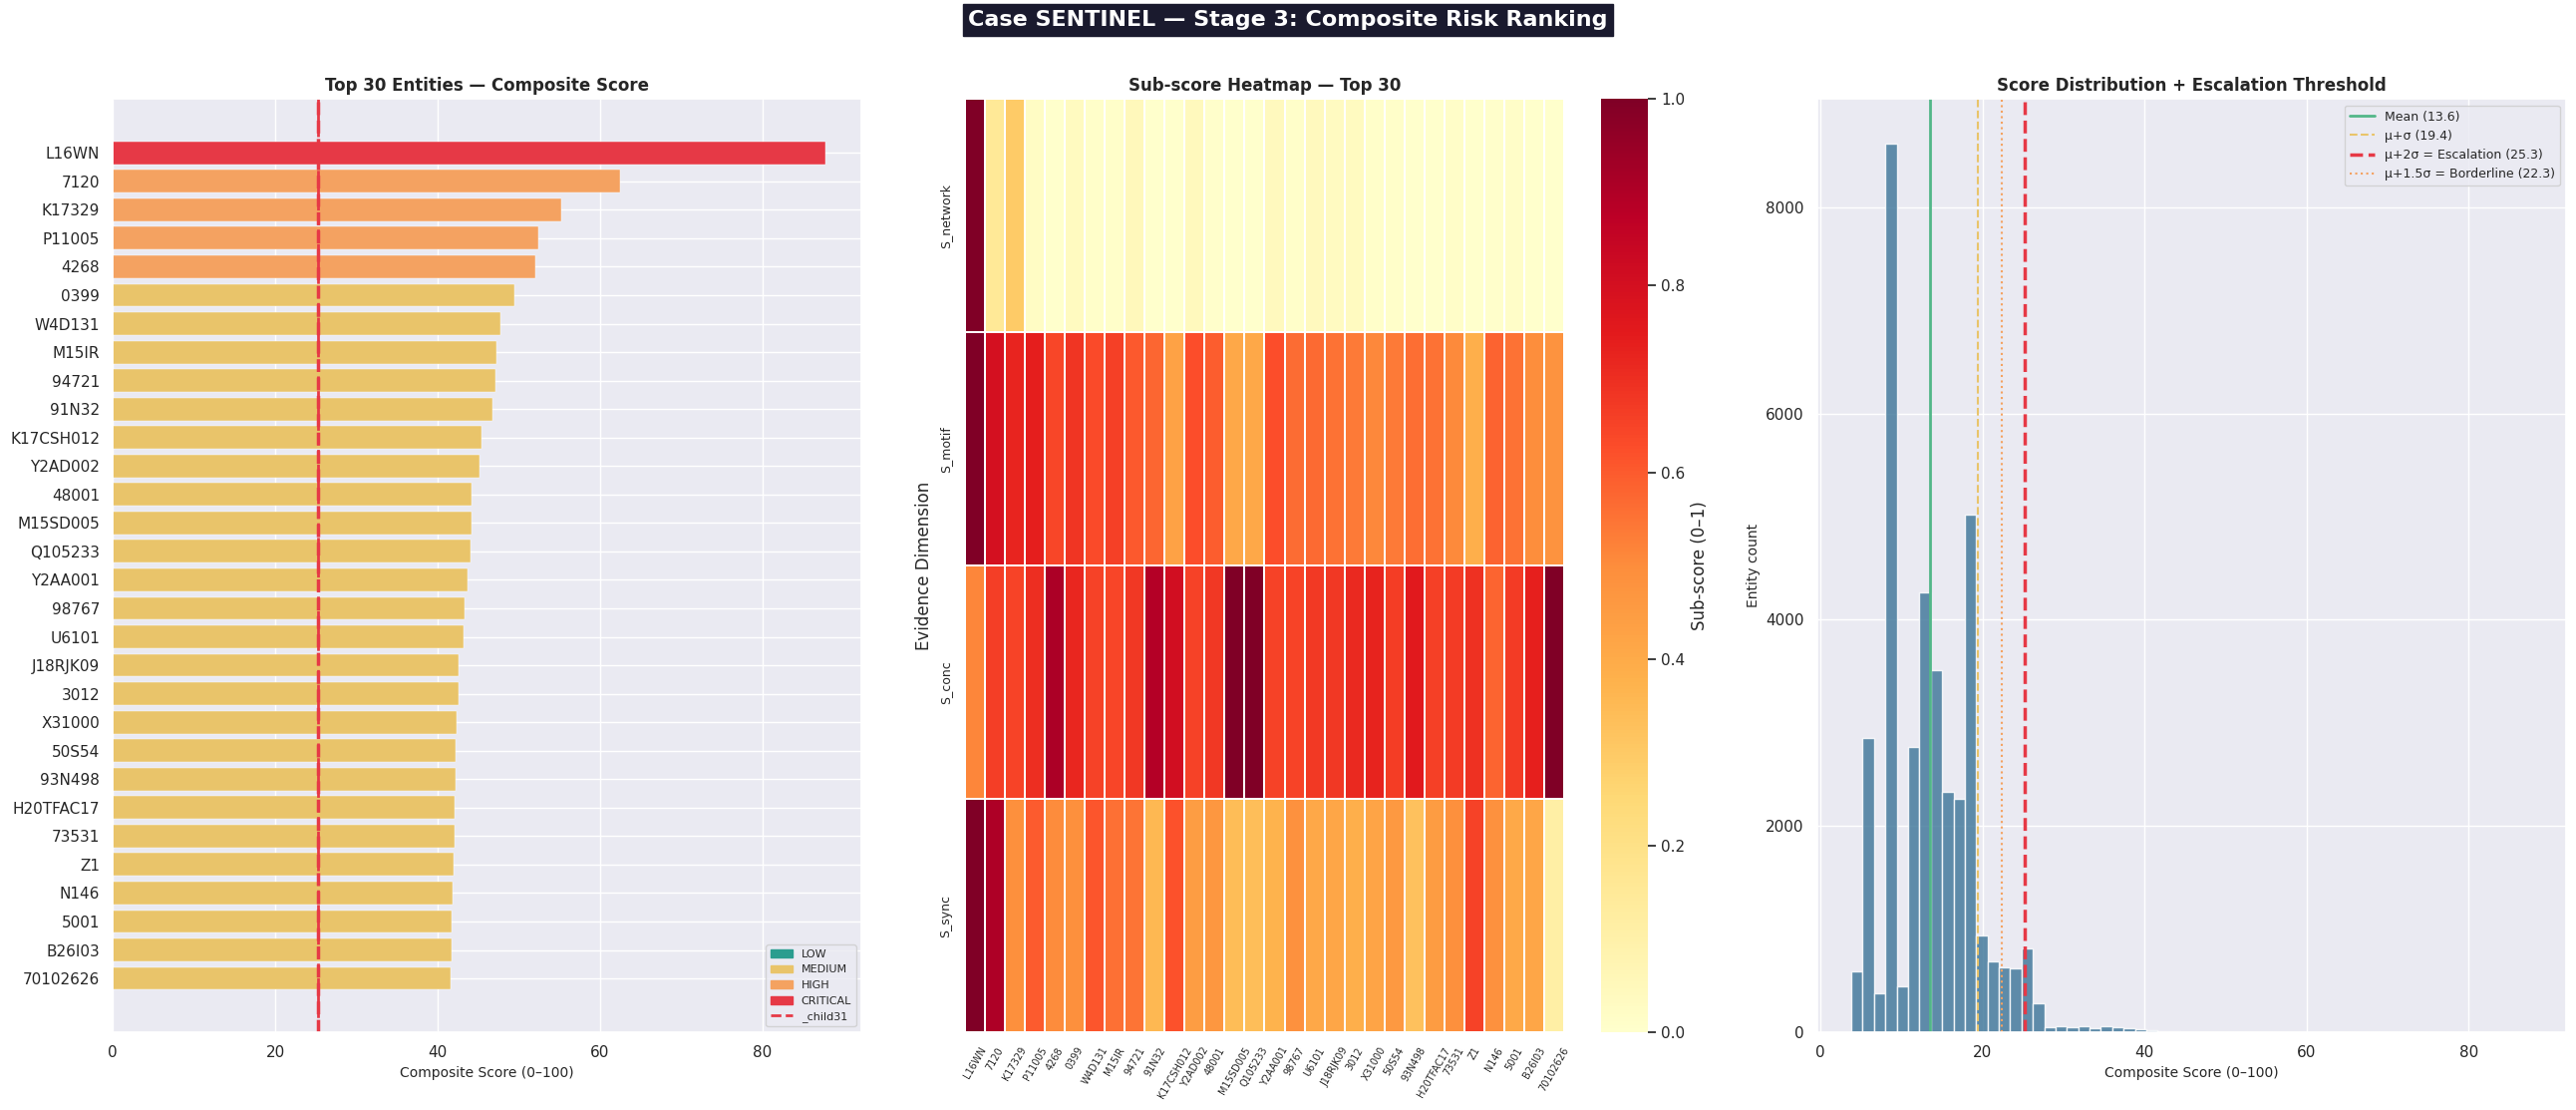

Fig 1 saved → s3_fig1_ranking.png


In [18]:
# ─────────────────────────────────────────────────────────────────────────────
# Section 7 — Ranking Visualisations (3-panel figure)
# ─────────────────────────────────────────────────────────────────────────────

TOP_N   = 30   # entities to display in charts
top30   = comp_sorted.head(TOP_N).copy()
esc_thr = mu + 2 * sigma   # escalation threshold on Score_100 scale

fig, axes = plt.subplots(1, 3, figsize=(26, 11))
fig.suptitle('Case SENTINEL — Stage 3: Composite Risk Ranking',
             fontsize=16, fontweight='bold',
             color='white', backgroundcolor='#1A1A2E', y=1.01)

# ── Panel A: Horizontal bar — Top 30 by composite score ─────────────────────
ax_a = axes[0]
tier_palette = {'LOW':'#2A9D8F','MEDIUM':'#E9C46A','HIGH':'#F4A261','CRITICAL':'#E63946'}
bar_colors = [tier_palette.get(str(t), '#888') for t in top30['Risk_Tier']]
ax_a.barh(top30['client'][::-1], top30['Score_100'][::-1],
          color=bar_colors[::-1], edgecolor='white', linewidth=0.3)
ax_a.axvline(esc_thr, color='#E63946', linewidth=2.5, linestyle='--',
             label=f'Escalation threshold\n(μ+2σ = {esc_thr:.1f})')
ax_a.set_xlabel('Composite Score (0–100)', fontsize=10)
ax_a.set_title(f'Top {TOP_N} Entities — Composite Score', fontweight='bold')
for patch in [mpatches.Patch(color=c, label=t) for t, c in tier_palette.items()]:
    pass
ax_a.legend(fontsize=9)
handles = [mpatches.Patch(color=c, label=t) for t, c in tier_palette.items()]
ax_a.legend(handles=handles + [ax_a.axvline(esc_thr, color='#E63946',
            linewidth=2, linestyle='--')], fontsize=8)

# ── Panel B: Sub-score heatmap for top 30 ────────────────────────────────────
ax_b = axes[1]
heat_data = top30.set_index('client')[['S_network','S_motif','S_conc','S_sync']].T
heat_data.columns = [str(c)[:12] for c in heat_data.columns]
sns.heatmap(heat_data, ax=ax_b, cmap='YlOrRd', vmin=0, vmax=1,
            linewidths=0.3, cbar_kws={'label': 'Sub-score (0–1)'},
            annot=(TOP_N <= 20), fmt='.2f', annot_kws={'size': 7})
ax_b.set_title(f'Sub-score Heatmap — Top {TOP_N}', fontweight='bold')
ax_b.set_xlabel(''); ax_b.set_ylabel('Evidence Dimension')
ax_b.tick_params(axis='x', rotation=60, labelsize=7)
ax_b.tick_params(axis='y', labelsize=9)

# ── Panel C: Score distribution with escalation threshold annotated ──────────
ax_c = axes[2]
scores_pos = comp_sorted[comp_sorted['Score_100'] > 0]['Score_100']
ax_c.hist(scores_pos, bins=60, color='#457B9D', edgecolor='white', alpha=0.85)
ax_c.axvline(mu,           color='#52B788', linewidth=2, linestyle='-',
             label=f'Mean ({mu:.1f})')
ax_c.axvline(mu + sigma,   color='#E9C46A', linewidth=1.5, linestyle='--',
             label=f'μ+σ ({mu+sigma:.1f})')
ax_c.axvline(mu + 2*sigma, color='#E63946', linewidth=2.5, linestyle='--',
             label=f'μ+2σ = Escalation ({mu+2*sigma:.1f})')
ax_c.axvline(mu + 1.5*sigma, color='#F4A261', linewidth=1.5, linestyle=':',
             label=f'μ+1.5σ = Borderline ({mu+1.5*sigma:.1f})')
ax_c.set_xlabel('Composite Score (0–100)', fontsize=10)
ax_c.set_ylabel('Entity count', fontsize=10)
ax_c.set_title('Score Distribution + Escalation Threshold', fontweight='bold')
ax_c.legend(fontsize=9)

plt.tight_layout()
plt.savefig(os.path.join(CHARTS_DIR, 's3_fig1_ranking.png'), dpi=150, bbox_inches='tight')
plt.show()
print(f'Fig 1 saved → s3_fig1_ranking.png')


## Section 8 — Select and Justify Escalated Entities (Up to 12)

Escalation criteria (ALL must be satisfied):
1. `Score_100 ≥ μ + 2σ` **OR** `evidence_dims ≥ 3` with `Score_100 ≥ μ + 1.5σ`
2. At least **2 independent evidence dimensions** must fire above threshold
3. Not classified as Likely HFT (false-positive protected)

For each escalated entity: `entity_id`, `classification`, `primary_evidence`, `confidence`, `structural_proof`.


In [19]:
# ─────────────────────────────────────────────────────────────────────────────
# Section 8 — Escalation Selection (up to 12) + Structured Justification
# ─────────────────────────────────────────────────────────────────────────────

esc_threshold  = mu + 2 * sigma
bord_threshold = mu + 1.5 * sigma

# ── Escalation gate function ──────────────────────────────────────────────────
def escalation_gate(row):
    """
    Returns True if entity clears the escalation bar.
    Rule A: composite ≥ μ+2σ  AND  evidence_dims ≥ 2
    Rule B: composite ≥ μ+1.5σ AND evidence_dims ≥ 3
    """
    sc  = row['Score_100']
    ed  = row['evidence_dims']
    if sc >= esc_threshold  and ed >= 2:
        return True
    if sc >= bord_threshold and ed >= 3:
        return True
    return False

comp_sorted['escalate'] = comp_sorted.apply(escalation_gate, axis=1)

# ── Select top 12 from escalated pool ────────────────────────────────────────
escalated = comp_sorted[comp_sorted['escalate']].head(12).copy().reset_index(drop=True)
escalated['esc_rank'] = escalated.index + 1

# ── Classification and confidence assignment ──────────────────────────────────
def assign_tier(row):
    if row['Score_100'] >= 75:
        return 'CRITICAL'
    elif row['Score_100'] >= 50:
        return 'HIGH'
    return 'HIGH'   # escalated entities are at minimum HIGH

def primary_evidence_type(row):
    """Identify which evidence dimension is the strongest driver."""
    dims = {
        'Network Structure'               : row['S_network'],
        'Motif Participation (Loops)'     : row['S_motif'],
        'Counterparty Concentration'      : row['S_conc'],
        'Temporal Synchronisation'        : row['S_sync'],
    }
    return max(dims, key=dims.get)

def confidence_level(row):
    ed = row['evidence_dims']
    sc = row['Score_100']
    if ed == 4 or sc >= esc_threshold + sigma:
        return 'HIGH'
    if ed == 3 or sc >= esc_threshold:
        return 'HIGH'
    return 'MEDIUM'

def structural_proof(row):
    """Compose a concise structural proof string."""
    parts = []
    if row['S_motif'] > 0.3:
        lc  = int(row['loop_count']) if row['loop_count'] > 0 else '?'
        sev = int(row['max_severity']) if row['max_severity'] > 0 else '?'
        pd_ = int(row['persist_days']) if row['persist_days'] > 0 else '?'
        mec = str(row['mechanisms'])[:40]
        parts.append(f'{lc} loops (sev={sev}, persist={pd_}d) [{mec}]')
    if row['S_network'] > 0.3:
        bet = f"{row.get('betweenness', 0):.4f}"
        pr  = f"{row.get('pagerank', 0):.5f}"
        rdg = f"{row.get('in_degree', 0):.4f}"
        parts.append(f'Betweenness={bet}, PageRank={pr}, InDeg={rdg}')
    if row['S_conc'] > 0.3:
        hhi  = f"{row.get('hhi', 0):.3f}"
        rec  = f"{row.get('reciprocity_ratio', 0):.3f}"
        wash = f"{row.get('wash_rate', 0):.3f}"
        parts.append(f'HHI={hhi}, Reciprocity={rec}, WashRate={wash}')
    if row['S_sync'] > 0.3:
        sp  = int(row['sync_pair_events'])
        rf  = int(row['rapid_fire'])
        sl  = int(row['in_sync_loop'])
        parts.append(f'SyncPairs={sp}, RapidFire={rf}, InSyncLoop={sl}')
    return ' | '.join(parts) if parts else 'Multi-dimension composite signal'

escalated['classification']   = escalated.apply(assign_tier, axis=1)
escalated['primary_evidence'] = escalated.apply(primary_evidence_type, axis=1)
escalated['confidence']       = escalated.apply(confidence_level, axis=1)
escalated['structural_proof'] = escalated.apply(structural_proof, axis=1)
escalated['s1_flags']         = escalated.apply(
    lambda r: '+'.join(filter(None, [
        'S1-Trade' if r['in_s1_trade'] else '',
        'S1-Order' if r['in_s1_order'] else '',
        'Loop'     if r['in_any_loop'] else '',
    ])) or 'New Entity', axis=1)

# ── Print the escalation table ────────────────────────────────────────────────
print('='*80)
print('  STAGE 3 — ESCALATION TABLE (UP TO 12 ENTITIES)')
print('='*80)
esc_cols = ['esc_rank','client','Score_100','classification','confidence',
            'primary_evidence','evidence_dims','s1_flags']
print(escalated[esc_cols].to_string(index=False))
print()
print('STRUCTURAL PROOF per entity:')
print('─'*80)
for _, row in escalated.iterrows():
    print(f"\n  [{row['esc_rank']:02d}] {row['client']}")
    print(f"       Classification : {row['classification']}")
    print(f"       Evidence type  : {row['primary_evidence']}")
    print(f"       Confidence     : {row['confidence']}")
    print(f"       Score (0-100)  : {row['Score_100']:.2f}  (z={row['z_score']:.2f})")
    print(f"       Dims firing    : {row['evidence_dims']}/4")
    print(f"       S1 flags       : {row['s1_flags']}")
    print(f"       Proof          : {row['structural_proof'][:120]}")
print()
print(f'Total escalated: {len(escalated)} / 12')

# ── Export to CSV ─────────────────────────────────────────────────────────────
esc_csv = os.path.join(CHARTS_DIR, 's3_escalation_table.csv')
escalated.to_csv(esc_csv, index=False)
print(f'\nEscalation table saved → {esc_csv}')


  STAGE 3 — ESCALATION TABLE (UP TO 12 ENTITIES)
 esc_rank    client  Score_100 classification confidence            primary_evidence  evidence_dims               s1_flags
        1     L16WN      87.84       CRITICAL       HIGH Motif Participation (Loops)              3 S1-Trade+S1-Order+Loop
        2      7120      62.49           HIGH       HIGH    Temporal Synchronisation              3          S1-Trade+Loop
        3    K17329      55.21           HIGH       HIGH Motif Participation (Loops)              3          S1-Trade+Loop
        4    P11005      52.43           HIGH       HIGH Motif Participation (Loops)              4          S1-Trade+Loop
        5      4268      52.05           HIGH       HIGH  Counterparty Concentration              4          S1-Trade+Loop
        6      0399      49.47           HIGH       HIGH  Counterparty Concentration              4          S1-Trade+Loop
        7    W4D131      47.72           HIGH       HIGH  Counterparty Concentration      

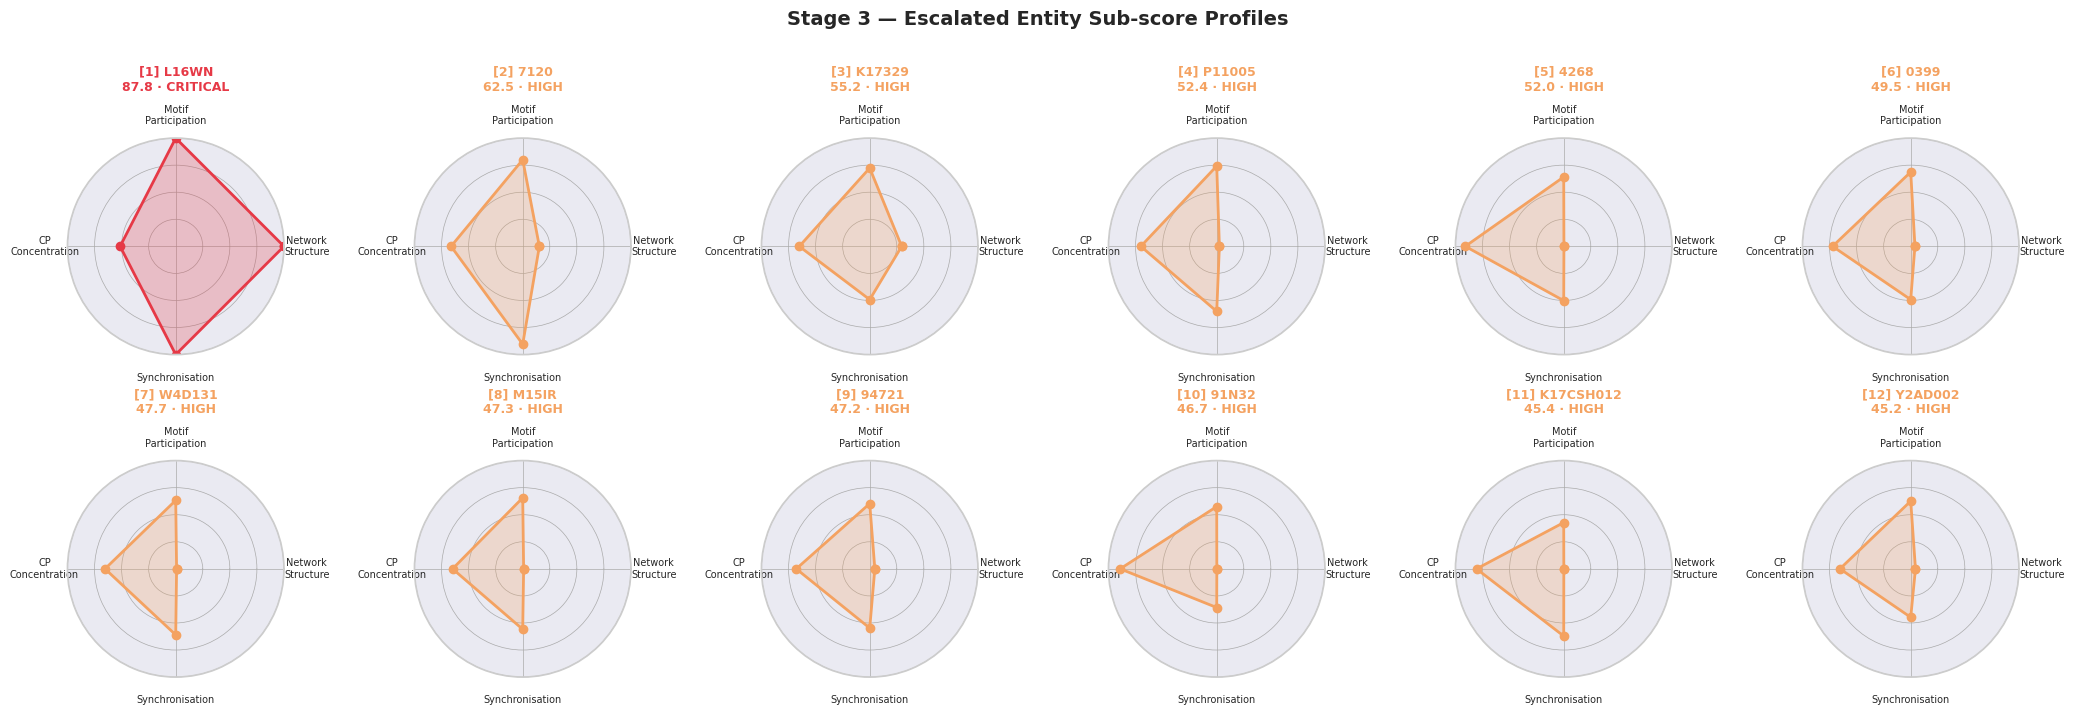

Radar chart saved → s3_fig2_radar.png


In [20]:
# ─────────────────────────────────────────────────────────────────────────────
# Section 8B — Radar / Spider chart per escalated entity (sub-score profile)
# ─────────────────────────────────────────────────────────────────────────────

import math

dims  = ['S_network','S_motif','S_conc','S_sync']
dlbls = ['Network\nStructure','Motif\nParticipation',
         'CP\nConcentration','Synchronisation']
N     = len(dims)
angles = [n / float(N) * 2 * math.pi for n in range(N)]
angles += angles[:1]

n_esc = len(escalated)
ncols = min(6, n_esc)
nrows = math.ceil(n_esc / ncols) if n_esc > 0 else 1
fig_r, ax_r = plt.subplots(nrows, ncols, figsize=(ncols * 3.5, nrows * 3.5),
                            subplot_kw={'projection': 'polar'})
if n_esc == 1:
    ax_r = [[ax_r]]
elif nrows == 1:
    ax_r = [ax_r]

tier_color_map = {'CRITICAL':'#E63946','HIGH':'#F4A261','MEDIUM':'#E9C46A','LOW':'#2A9D8F'}

for idx, (_, row) in enumerate(escalated.iterrows()):
    r_idx = idx // ncols
    c_idx = idx  % ncols
    ax = ax_r[r_idx][c_idx]

    values = [row[d] for d in dims] + [row[dims[0]]]
    color  = tier_color_map.get(row['classification'], '#888')

    ax.plot(angles, values, 'o-', linewidth=2, color=color)
    ax.fill(angles, values, alpha=0.25, color=color)
    ax.set_xticks(angles[:-1])
    ax.set_xticklabels(dlbls, size=7)
    ax.set_ylim(0, 1)
    ax.set_yticks([0.25, 0.5, 0.75, 1.0])
    ax.set_yticklabels(['','','',''], size=5)
    ax.set_title(f"[{row['esc_rank']}] {row['client']}\n{row['Score_100']:.1f} · {row['classification']}",
                 size=9, fontweight='bold', color=color, pad=10)
    ax.spines['polar'].set_color('#cccccc')
    ax.grid(color='#aaaaaa', linewidth=0.5)

# hide any unused subplots
for extra in range(n_esc, nrows * ncols):
    r_idx = extra // ncols
    c_idx = extra  % ncols
    ax_r[r_idx][c_idx].set_visible(False)

fig_r.suptitle('Stage 3 — Escalated Entity Sub-score Profiles',
               fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig(os.path.join(CHARTS_DIR, 's3_fig2_radar.png'), dpi=150, bbox_inches='tight')
plt.show()
print('Radar chart saved → s3_fig2_radar.png')


## Section 9 — False Positive Control Analysis

Three-layer filter to prevent over-escalation:
1. **Minimum evidence breadth** — both `evidence_dims ≥ 2` and `in_any_loop OR wash_rate > 0.3`
2. **Z-score outlier floor** — `Score_100 > μ + 2σ` (statistical outlier in the risk universe)
3. **Known-benign anchor check** — clients appearing only in Stage 1 suspect list but clearing HFT criteria are excluded


  FALSE POSITIVE CONTROL — GATE PASS/FAIL SUMMARY
  L1 — Evidence breadth (dims≥2 + loop/wash)         PASS=   651  FAIL=36,821
  L2 — Z-score outlier (z ≥ 2.0)                     PASS= 1,462  FAIL=36,010
  L3 — Not Likely HFT                                PASS=34,319  FAIL= 3,153

  Combined (ALL 3 layers) — PASS  : 473
  Combined (ALL 3 layers) — FAIL  : 36,999

S1 suspects reclassified as Likely HFT (cleared): 376
  client  Score_100  total_cp  loop_count  wash_rate   S_sync
   T7K79      23.08      55.0         0.0        0.1 0.181090
  Y2KJ02      22.89      18.0         0.0        0.1 0.197544
Y2110556      22.78      26.0         0.0        0.1 0.181090
 N14D004      22.70      45.0         0.0        0.1 0.189989
 Z1N9001      22.35      22.0         0.0        0.1 0.166933
   Z1E10      22.26      35.0         0.0        0.1 0.198223
 K171427      22.20      21.0         0.0        0.1 0.160912
    5405      21.63      23.0         0.0        0.1 0.123540
T7NP3B09      21.53

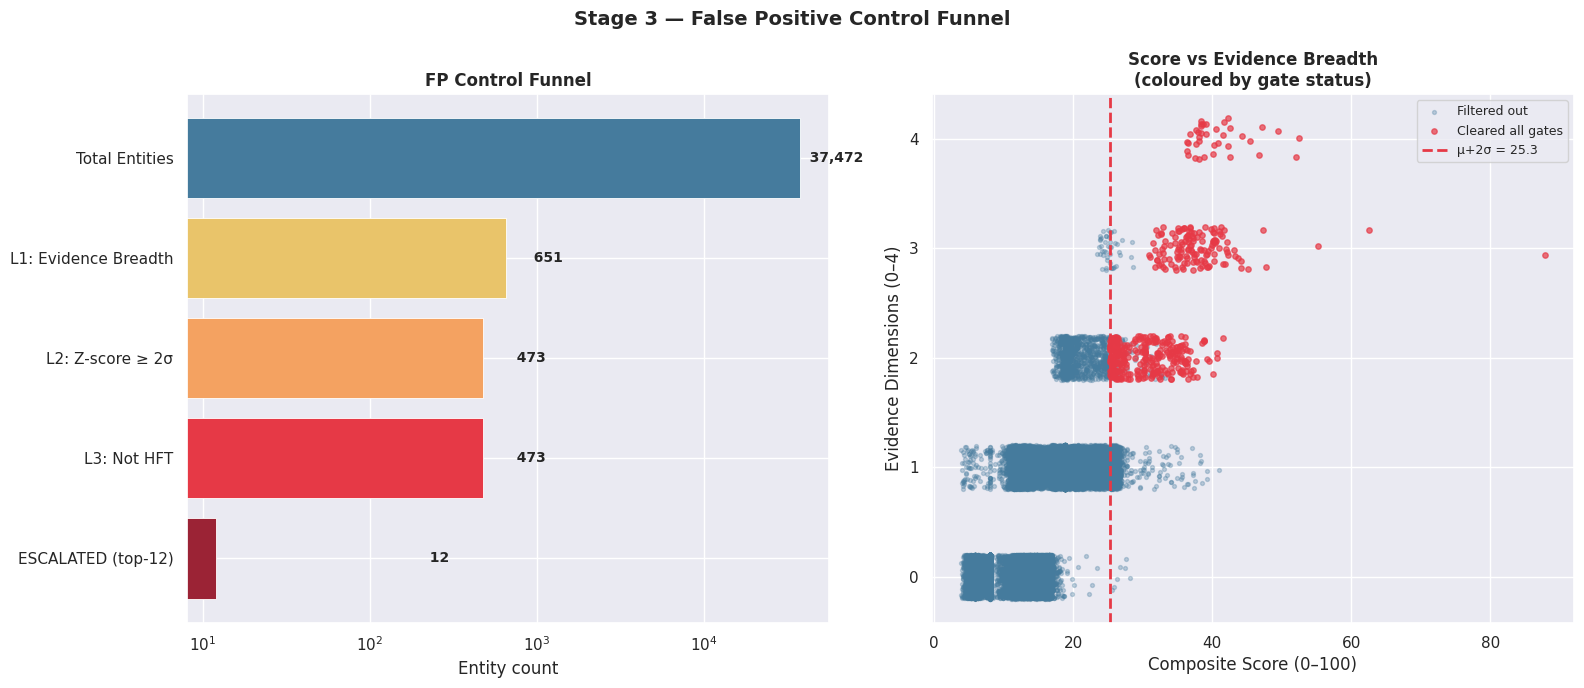

FP control chart saved → s3_fig3_fp_control.png


In [21]:
# ─────────────────────────────────────────────────────────────────────────────
# Section 9 — False Positive Control
# ─────────────────────────────────────────────────────────────────────────────

# ── Layer 1: Evidence breadth gate ───────────────────────────────────────────
comp_sorted['gate_L1'] = (
    (comp_sorted['evidence_dims'] >= 2) &
    (comp_sorted['in_any_loop'] | (comp_sorted['wash_rate'] > 0.3))
)

# ── Layer 2: Z-score outlier floor ────────────────────────────────────────────
comp_sorted['gate_L2'] = comp_sorted['z_score'] >= 2.0

# ── Layer 3: HFT benign anchor check ─────────────────────────────────────────
# HFT fingerprint: total_cp > 15 AND loop_count == 0 AND wash_rate < 0.2
comp_sorted['likely_hft'] = (
    (comp_sorted['total_cp'] > 15) &
    (comp_sorted['loop_count'] == 0) &
    (comp_sorted['wash_rate'] < 0.2) &
    (comp_sorted['S_sync'] < 0.2)
)
comp_sorted['gate_L3'] = ~comp_sorted['likely_hft']

# ── Combined gate ─────────────────────────────────────────────────────────────
comp_sorted['pass_all_gates'] = (
    comp_sorted['gate_L1'] &
    comp_sorted['gate_L2'] &
    comp_sorted['gate_L3']
)

# ── Confusion-style summary ────────────────────────────────────────────────────
print('='*65)
print('  FALSE POSITIVE CONTROL — GATE PASS/FAIL SUMMARY')
print('='*65)
layer_labels = {
    'gate_L1' : 'L1 — Evidence breadth (dims≥2 + loop/wash)',
    'gate_L2' : 'L2 — Z-score outlier (z ≥ 2.0)',
    'gate_L3' : 'L3 — Not Likely HFT',
}
for g, lbl in layer_labels.items():
    pass_n = comp_sorted[g].sum()
    fail_n = (~comp_sorted[g]).sum()
    print(f'  {lbl:<50} PASS={pass_n:>6,}  FAIL={fail_n:>6,}')
final_pass = comp_sorted['pass_all_gates'].sum()
print(f'\n  Combined (ALL 3 layers) — PASS  : {final_pass:,}')
print(f'  Combined (ALL 3 layers) — FAIL  : {(~comp_sorted["pass_all_gates"]).sum():,}')

# ── HFT entities that were on S1 suspect list (confirmed false positives) ─────
hft_fp = comp_sorted[
    comp_sorted['likely_hft'] & comp_sorted['in_s1_trade']
]
print(f'\nS1 suspects reclassified as Likely HFT (cleared): {len(hft_fp):,}')
if not hft_fp.empty:
    print(hft_fp[['client','Score_100','total_cp','loop_count','wash_rate','S_sync']]
          .head(10).to_string(index=False))

# ── Layer-by-layer funnel bar chart ───────────────────────────────────────────
fig_fp, axes_fp = plt.subplots(1, 2, figsize=(16, 7))
fig_fp.suptitle('Stage 3 — False Positive Control Funnel', fontsize=14, fontweight='bold')

# Left: horizontal funnel bars
ax_f = axes_fp[0]
stages = ['Total Entities', 'L1: Evidence Breadth', 'L2: Z-score ≥ 2σ',
          'L3: Not HFT', 'ESCALATED (top-12)']
vals   = [
    len(comp_sorted),
    comp_sorted['gate_L1'].sum(),
    (comp_sorted['gate_L1']  & comp_sorted['gate_L2']).sum(),
    (comp_sorted['gate_L1']  & comp_sorted['gate_L2'] & comp_sorted['gate_L3']).sum(),
    len(escalated),
]
funnel_colors = ['#457B9D','#E9C46A','#F4A261','#E63946','#9B2335']
bars = ax_f.barh(stages[::-1], vals[::-1], color=funnel_colors[::-1],
                 edgecolor='white', linewidth=0.6)
for bar, v in zip(bars, vals[::-1]):
    ax_f.text(v + max(vals)*0.005, bar.get_y() + bar.get_height()/2,
              f'  {v:,}', va='center', fontsize=10, fontweight='bold')
ax_f.set_xlabel('Entity count')
ax_f.set_title('FP Control Funnel', fontweight='bold')
ax_f.set_xscale('log')

# Right: scatter of score vs evidence_dims, coloured by pass/fail
ax_s = axes_fp[1]
passed_mask = comp_sorted['pass_all_gates']
ax_s.scatter(comp_sorted.loc[~passed_mask, 'Score_100'],
             comp_sorted.loc[~passed_mask, 'evidence_dims'] + np.random.uniform(-0.2, 0.2, (~passed_mask).sum()),
             c='#457B9D', alpha=0.3, s=8, label='Filtered out')
ax_s.scatter(comp_sorted.loc[passed_mask, 'Score_100'],
             comp_sorted.loc[passed_mask, 'evidence_dims'] + np.random.uniform(-0.2, 0.2, passed_mask.sum()),
             c='#E63946', alpha=0.7, s=15, label='Cleared all gates')
ax_s.axvline(esc_threshold, color='#E63946', linewidth=2, linestyle='--',
             label=f'μ+2σ = {esc_threshold:.1f}')
ax_s.set_xlabel('Composite Score (0–100)')
ax_s.set_ylabel('Evidence Dimensions (0–4)')
ax_s.set_title('Score vs Evidence Breadth\n(coloured by gate status)', fontweight='bold')
ax_s.legend(fontsize=9)
ax_s.set_yticks([0,1,2,3,4])

plt.tight_layout()
plt.savefig(os.path.join(CHARTS_DIR, 's3_fig3_fp_control.png'), dpi=150, bbox_inches='tight')
plt.show()
print('FP control chart saved → s3_fig3_fp_control.png')


## Section 10 — Borderline Entities: Exclusion Rationale Log

Borderline entities: `Score_100 ∈ [μ+1.5σ, μ+2σ)` OR ranked 13th–25th in the scored universe.  
For each, document which sub-scores drove elevation and why they do not cross the escalation bar.


In [22]:
# ─────────────────────────────────────────────────────────────────────────────
# Section 10 — Borderline Entities: Exclusion Log
# ─────────────────────────────────────────────────────────────────────────────

escalated_ids = set(escalated['client'])

# Candidates: ranked 13-25 OR in [μ+1.5σ, μ+2σ) — not in escalated set
borderline = comp_sorted[
    (~comp_sorted['client'].isin(escalated_ids)) &
    (
        (comp_sorted['rank'] <= 25) |
        (
            (comp_sorted['Score_100'] >= bord_threshold) &
            (comp_sorted['Score_100'] <  esc_threshold)
        )
    )
].copy().head(15)

# ── Build exclusion rationale per entity ─────────────────────────────────────
def exclusion_rationale(row):
    reasons = []
    # Which dims are elevated
    high_dims = []
    if row['S_network'] > 0.4:
        high_dims.append('Network')
    if row['S_motif']   > 0.4:
        high_dims.append('Motif')
    if row['S_conc']    > 0.4:
        high_dims.append('Concentration')
    if row['S_sync']    > 0.4:
        high_dims.append('Sync')
    low_dims = [d for d in ['Network','Motif','Concentration','Sync'] if d not in high_dims]

    if len(high_dims) == 1:
        reasons.append(f'Single-dimension elevation ({high_dims[0]}) — insufficient cross-corroboration')

    if row['loop_count'] == 0:
        reasons.append('No confirmed loop participation — motif signal absent')

    if row['likely_hft']:
        reasons.append(f'HFT profile: {int(row["total_cp"])} unique CPs, no loops, low sync — likely structural hub')

    if row['evidence_dims'] < 2:
        reasons.append(f'Only {int(row["evidence_dims"])}/4 evidence dimensions activated — below minimum breadth')

    if row['Score_100'] < esc_threshold:
        gap = esc_threshold - row['Score_100']
        reasons.append(f'Score {row["Score_100"]:.1f} falls {gap:.1f} pts below μ+2σ escalation bar ({esc_threshold:.1f})')

    if row['reciprocity_ratio'] < 0.3 and row['loop_count'] == 0:
        reasons.append('Low reciprocity without loop confirmation — suggests directional flow, not circular wash')

    if not reasons:
        reasons.append(f'Ranked {int(row["rank"])} — displaced by 12 higher-priority entities with broader corroboration')

    if low_dims:
        reasons.append(f'Weak dimensions: {", ".join(low_dims)}')

    return ' | '.join(reasons)

borderline['exclusion_rationale'] = borderline.apply(exclusion_rationale, axis=1)
borderline['driving_dims'] = borderline.apply(
    lambda r: '+'.join(d for d, sc in [('Net',r['S_network']),('Mot',r['S_motif']),
                                         ('Conc',r['S_conc']),('Sync',r['S_sync'])]
                       if sc > 0.4) or 'None', axis=1)

# ── Print exclusion log ───────────────────────────────────────────────────────
print('='*80)
print('  STAGE 3 — BORDERLINE ENTITIES: EXCLUSION LOG')
print('='*80)
print(f'\nEscalation threshold     : {esc_threshold:.2f} (μ+2σ)')
print(f'Borderline floor         : {bord_threshold:.2f} (μ+1.5σ)')
print(f'Borderline entities shown: {len(borderline)}')
print()

for i, (_, row) in enumerate(borderline.iterrows()):
    print(f"  [{i+1:02d}] Entity       : {row['client']}")
    print(f"       Global rank   : {int(row['rank'])}")
    print(f"       Score         : {row['Score_100']:.2f}  (z={row['z_score']:.2f})")
    print(f"       Dims active   : {row['driving_dims']}  ({int(row['evidence_dims'])}/4 ≥ 0.4)")
    print(f"       S_net|mot|con|syn = "
          f"{row['S_network']:.3f} | {row['S_motif']:.3f} | "
          f"{row['S_conc']:.3f} | {row['S_sync']:.3f}")
    print(f"       EXCLUSION     : {row['exclusion_rationale'][:120]}")
    print()

# ── Export borderline log ─────────────────────────────────────────────────────
bl_csv = os.path.join(CHARTS_DIR, 's3_borderline_exclusion_log.csv')
borderline[['client','rank','Score_100','z_score','evidence_dims',
            'S_network','S_motif','S_conc','S_sync',
            'driving_dims','exclusion_rationale']].to_csv(bl_csv, index=False)
print(f'Borderline exclusion log saved → {bl_csv}')


  STAGE 3 — BORDERLINE ENTITIES: EXCLUSION LOG

Escalation threshold     : 25.25 (μ+2σ)
Borderline floor         : 22.34 (μ+1.5σ)
Borderline entities shown: 15

  [01] Entity       : 48001
       Global rank   : 13
       Score         : 44.22  (z=5.25)
       Dims active   : Mot+Conc+Sync  (4/4 ≥ 0.4)
       S_net|mot|con|syn = 0.005 | 0.595 | 0.677 | 0.466
       EXCLUSION     : Ranked 13 — displaced by 12 higher-priority entities with broader corroboration | Weak dimensions: Network

  [02] Entity       : M15SD005
       Global rank   : 14
       Score         : 44.13  (z=5.24)
       Dims active   : Mot+Conc  (3/4 ≥ 0.4)
       S_net|mot|con|syn = 0.000 | 0.409 | 1.000 | 0.342
       EXCLUSION     : Ranked 14 — displaced by 12 higher-priority entities with broader corroboration | Weak dimensions: Network, Sync

  [03] Entity       : Q105233
       Global rank   : 15
       Score         : 44.08  (z=5.23)
       Dims active   : Mot+Conc  (3/4 ≥ 0.4)
       S_net|mot|con|syn = 0.000 

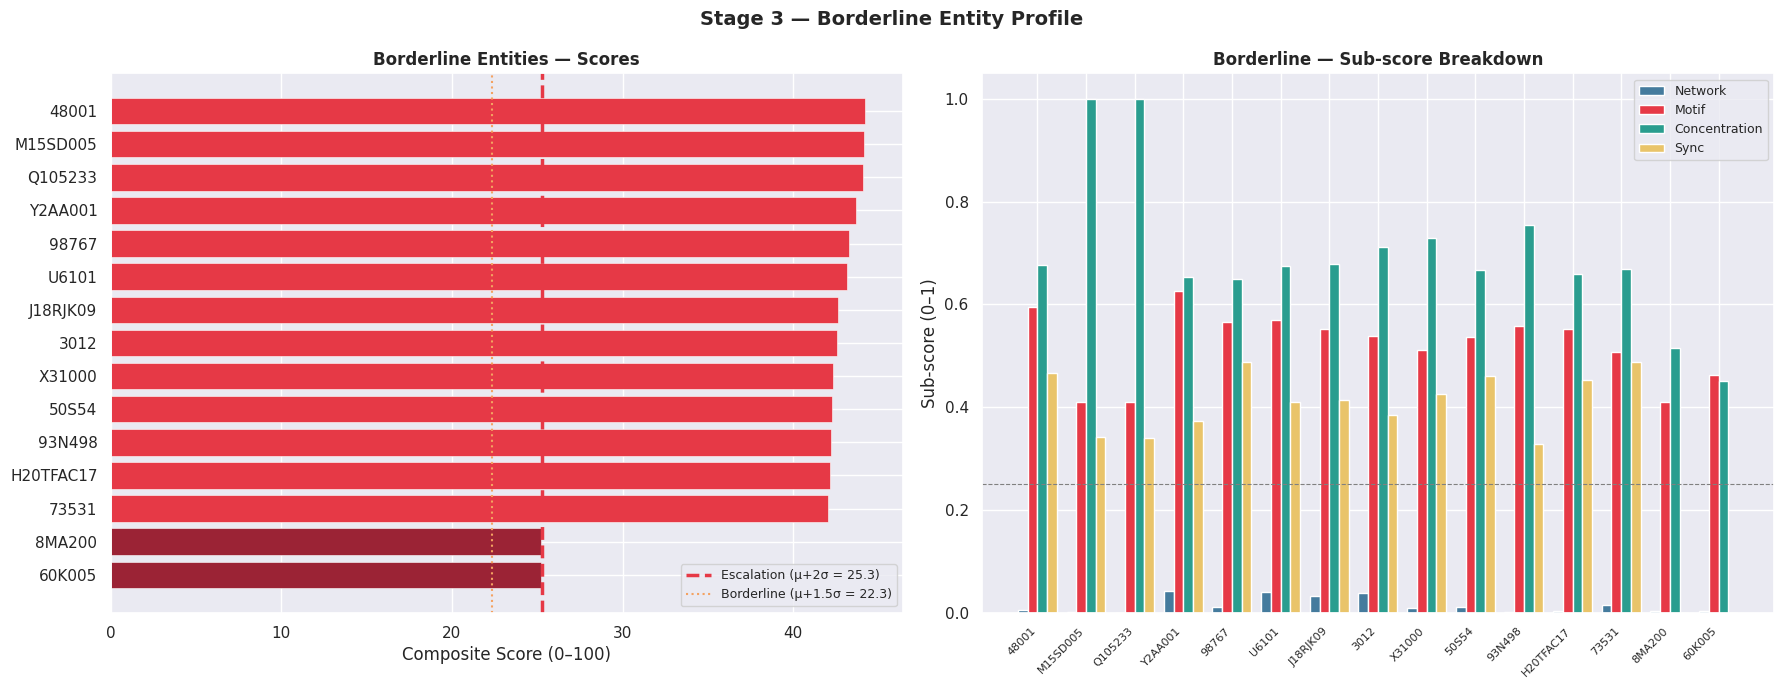

Borderline chart saved → s3_fig4_borderline.png


In [23]:
# ─────────────────────────────────────────────────────────────────────────────
# Section 10B — Borderline Visualisation: Score vs Evidence Breadth
# ─────────────────────────────────────────────────────────────────────────────

fig_bl, axes_bl = plt.subplots(1, 2, figsize=(18, 7))
fig_bl.suptitle('Stage 3 — Borderline Entity Profile', fontsize=14, fontweight='bold')

# Left: bar chart of borderline scores
ax_bl = axes_bl[0]
bl_colors = ['#9B2335' if r['Score_100'] < esc_threshold else '#E63946'
             for _, r in borderline.iterrows()]
ax_bl.barh(borderline['client'][::-1],
           borderline['Score_100'][::-1],
           color=bl_colors[::-1], edgecolor='white', linewidth=0.4)
ax_bl.axvline(esc_threshold,  color='#E63946', linewidth=2.5, linestyle='--',
              label=f'Escalation (μ+2σ = {esc_threshold:.1f})')
ax_bl.axvline(bord_threshold, color='#F4A261', linewidth=1.5, linestyle=':',
              label=f'Borderline (μ+1.5σ = {bord_threshold:.1f})')
ax_bl.set_xlabel('Composite Score (0–100)')
ax_bl.set_title('Borderline Entities — Scores', fontweight='bold')
ax_bl.legend(fontsize=9)

# Right: sub-score grouped bar per borderline entity
ax_br = axes_bl[1]
bx = np.arange(len(borderline))
w = 0.2
bl = borderline.reset_index(drop=True)
ax_br.bar(bx - 1.5*w, bl['S_network'], w, label='Network',      color='#457B9D')
ax_br.bar(bx - 0.5*w, bl['S_motif'],   w, label='Motif',        color='#E63946')
ax_br.bar(bx + 0.5*w, bl['S_conc'],    w, label='Concentration', color='#2A9D8F')
ax_br.bar(bx + 1.5*w, bl['S_sync'],    w, label='Sync',         color='#E9C46A')
ax_br.set_xticks(bx)
ax_br.set_xticklabels(bl['client'], rotation=45, ha='right', fontsize=8)
ax_br.set_ylabel('Sub-score (0–1)')
ax_br.set_ylim(0, 1.05)
ax_br.set_title('Borderline — Sub-score Breakdown', fontweight='bold')
ax_br.legend(fontsize=9)
ax_br.axhline(0.25, color='gray', linestyle='--', linewidth=0.8)

plt.tight_layout()
plt.savefig(os.path.join(CHARTS_DIR, 's3_fig4_borderline.png'), dpi=150, bbox_inches='tight')
plt.show()
print('Borderline chart saved → s3_fig4_borderline.png')


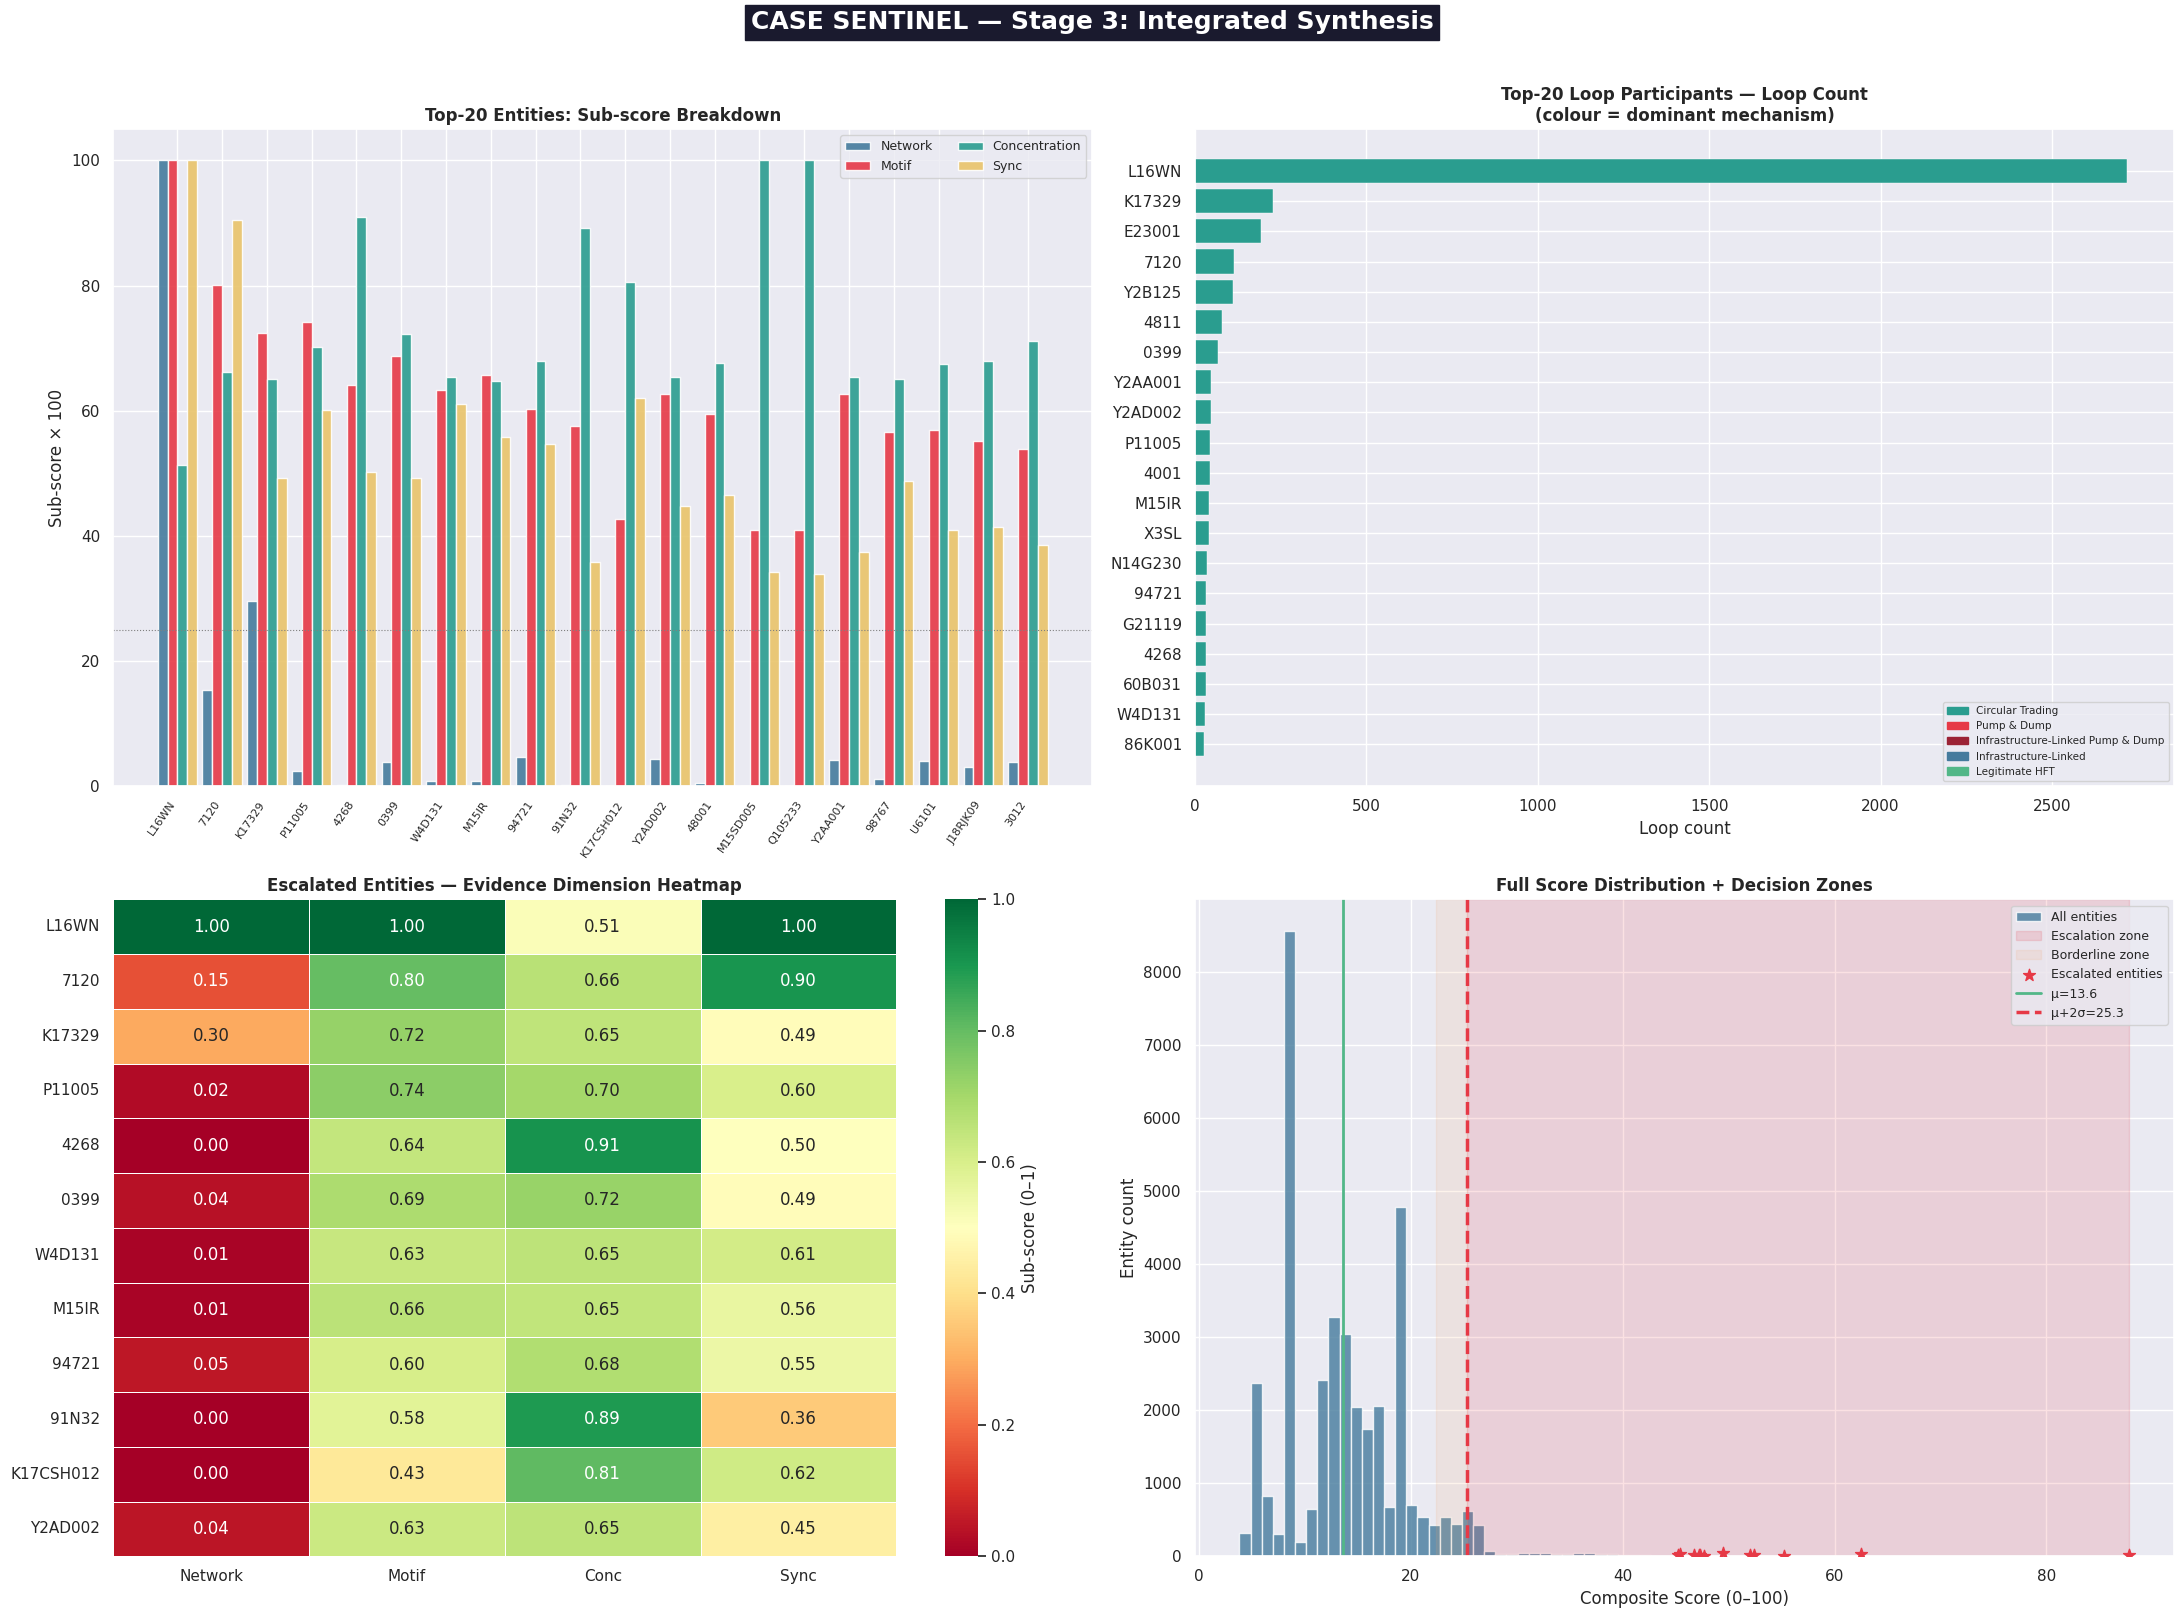

Integrated figure saved → s3_fig5_integrated.png


In [24]:
# ─────────────────────────────────────────────────────────────────────────────
# FINAL COMPREHENSIVE FIGURE — Stage-by-stage integrated picture (4-panel)
# ─────────────────────────────────────────────────────────────────────────────

fig_f, axes_f = plt.subplots(2, 2, figsize=(22, 16))
fig_f.suptitle('CASE SENTINEL — Stage 3: Integrated Synthesis',
               fontsize=18, fontweight='bold',
               color='white', backgroundcolor='#1A1A2E', y=1.01)

# ── A: Cross-stage risk score comparison for top-20 ─────────────────────────
ax_a = axes_f[0, 0]
top20_comp = comp_sorted.head(20).copy()
x = np.arange(len(top20_comp))
w = 0.22
ax_a.bar(x - 1.5*w, top20_comp['S_network']*100, w, label='Network',      color='#457B9D', alpha=0.9)
ax_a.bar(x - 0.5*w, top20_comp['S_motif']*100,   w, label='Motif',        color='#E63946', alpha=0.9)
ax_a.bar(x + 0.5*w, top20_comp['S_conc']*100,    w, label='Concentration', color='#2A9D8F', alpha=0.9)
ax_a.bar(x + 1.5*w, top20_comp['S_sync']*100,    w, label='Sync',         color='#E9C46A', alpha=0.9)
ax_a.set_xticks(x)
ax_a.set_xticklabels(top20_comp['client'], rotation=55, ha='right', fontsize=8)
ax_a.set_ylabel('Sub-score × 100')
ax_a.set_title('Top-20 Entities: Sub-score Breakdown', fontweight='bold')
ax_a.legend(fontsize=9, ncol=2)
ax_a.axhline(25, color='gray', linestyle=':', linewidth=0.8)

# ── B: Loop volume treemap effect (bar chart by loop volume for top loop participants) ─
ax_b = axes_f[0, 1]
if not motif_df.empty:
    top_motif = motif_df.nlargest(20, 'loop_count').copy()
    mech_pal = {
        'Circular Trading'                     : '#2A9D8F',
        'Pump & Dump'                          : '#E63946',
        'Infrastructure-Linked Pump & Dump'    : '#9B2335',
        'Infrastructure-Linked'                : '#457B9D',
        'Legitimate HFT'                       : '#52B788',
    }
    bar_c2 = [mech_pal.get(str(m).split(' | ')[0], '#888')
              for m in top_motif['mechanisms']]
    ax_b.barh(top_motif['client'][::-1], top_motif['loop_count'][::-1],
              color=bar_c2[::-1], edgecolor='white', linewidth=0.3)
    ax_b.set_xlabel('Loop count')
    ax_b.set_title('Top-20 Loop Participants — Loop Count\n(colour = dominant mechanism)',
                   fontweight='bold')
    patches_m = [mpatches.Patch(color=c, label=m) for m, c in mech_pal.items()]
    ax_b.legend(handles=patches_m, fontsize=7.5, loc='lower right')

# ── C: Evidence dimension coverage per escalated entity ─────────────────────
ax_c = axes_f[1, 0]
if not escalated.empty:
    esc_matrix = escalated.set_index('client')[['S_network','S_motif','S_conc','S_sync']]
    esc_matrix.columns = ['Network','Motif','Conc','Sync']
    esc_matrix.index   = [str(c)[:14] for c in esc_matrix.index]
    sns.heatmap(esc_matrix, ax=ax_c, cmap='RdYlGn', vmin=0, vmax=1,
                linewidths=0.5, annot=True, fmt='.2f',
                cbar_kws={'label': 'Sub-score (0–1)'})
    ax_c.set_title('Escalated Entities — Evidence Dimension Heatmap', fontweight='bold')
    ax_c.tick_params(axis='x', rotation=0); ax_c.tick_params(axis='y', rotation=0)

# ── D: Score distribution with escalated + borderline + FP zones highlighted ─
ax_d = axes_f[1, 1]
scores_all = comp_sorted[comp_sorted['Score_100'] > 0]['Score_100']
ax_d.hist(scores_all, bins=80, color='#457B9D', edgecolor='white', alpha=0.8, label='All entities')
ax_d.axvspan(esc_threshold, scores_all.max(), alpha=0.15, color='#E63946', label='Escalation zone')
ax_d.axvspan(bord_threshold, esc_threshold,   alpha=0.12, color='#F4A261', label='Borderline zone')
esc_scores = escalated['Score_100']
ax_d.scatter(esc_scores,
             np.random.uniform(1, 50, len(esc_scores)),
             c='#E63946', s=80, zorder=5, marker='*', label='Escalated entities')
ax_d.axvline(mu,           color='#52B788', linewidth=2,   linestyle='-',  label=f'μ={mu:.1f}')
ax_d.axvline(esc_threshold, color='#E63946', linewidth=2.5, linestyle='--',
             label=f'μ+2σ={esc_threshold:.1f}')
ax_d.set_xlabel('Composite Score (0–100)'); ax_d.set_ylabel('Entity count')
ax_d.set_title('Full Score Distribution + Decision Zones', fontweight='bold')
ax_d.legend(fontsize=9)

plt.tight_layout()
plt.savefig(os.path.join(CHARTS_DIR, 's3_fig5_integrated.png'), dpi=150, bbox_inches='tight')
plt.show()
print('Integrated figure saved → s3_fig5_integrated.png')


In [25]:
# ─────────────────────────────────────────────────────────────────────────────
# STAGE 3 — CONSOLIDATED FINDINGS SUMMARY
# ─────────────────────────────────────────────────────────────────────────────

print('═'*80)
print('  CASE SENTINEL — STAGE 3 CONSOLIDATED FINDINGS')
print('  Integrated Evidence Synthesis | DECODE X | March 2026')
print('═'*80)

print('\n◾ EVIDENCE INTEGRATION')
print(f'  Network structure entities analysed : {len(net_df):,}')
print(f'  Motif participants (all loops)      : {len(motif_df):,}')
print(f'  Counterparty concentration universe : {len(conc_df):,}')
print(f'  Synchronization evidence entities   : {(sync_df["S_sync"] > 0).sum():,}')
print(f'  COMPOSITE universe                  : {len(comp_sorted):,}')

print('\n◾ COMPOSITE RISK DISTRIBUTION')
for tier in ['CRITICAL','HIGH','MEDIUM','LOW']:
    n = (comp_sorted['Risk_Tier'] == tier).sum()
    print(f'  {tier:<12}: {n:>7,}')

print(f'\n◾ FALSE POSITIVE CONTROL')
print(f'  Entities filtered by L1 (breadth)   : {(~comp_sorted["gate_L1"]).sum():,}')
print(f'  Entities filtered by L2 (z-score)   : {(~comp_sorted["gate_L2"]).sum():,}')
print(f'  Likely HFT identified (L3)           : {comp_sorted["likely_hft"].sum():,}')
print(f'  S1 suspects cleared as HFT           : {(comp_sorted["likely_hft"] & comp_sorted["in_s1_trade"]).sum():,}')

print(f'\n◾ FINAL ESCALATION')
print(f'  Entities cleared all gates           : {comp_sorted["pass_all_gates"].sum():,}')
print(f'  Selected for escalation              : {len(escalated)} / 12')
print(f'  CRITICAL tier                        : {(escalated["classification"] == "CRITICAL").sum()}')
print(f'  HIGH tier                            : {(escalated["classification"] == "HIGH").sum()}')
print(f'  Multi-source corroboration (dims≥3)  : {(escalated["evidence_dims"] >= 3).sum()}')

print(f'\n◾ BORDERLINE (NOT ESCALATED)')
print(f'  Entities in borderline zone          : {len(borderline)}')
print(f'  Common exclusion reasons:')
reasons_log = borderline['exclusion_rationale'].value_counts()
for r, c in reasons_log.head(5).items():
    print(f'    [{c}x] {str(r)[:72]}')

print(f'\n◾ CHARTS SAVED')
for f in ['s3_fig1_ranking.png','s3_fig2_radar.png','s3_fig3_fp_control.png',
          's3_fig4_borderline.png','s3_fig5_integrated.png']:
    p = os.path.join(CHARTS_DIR, f)
    status = '✓' if os.path.exists(p) else '✗'
    print(f'  {status} {f}')

print(f'\n◾ CSV EXPORTS')
for f in ['s3_escalation_table.csv','s3_borderline_exclusion_log.csv']:
    p = os.path.join(CHARTS_DIR, f)
    status = '✓' if os.path.exists(p) else '✗'
    print(f'  {status} {f}')

print('\n' + '═'*80)
print('  Stage 3 complete. Findings ready for enforcement review.')
print('═'*80)


════════════════════════════════════════════════════════════════════════════════
  CASE SENTINEL — STAGE 3 CONSOLIDATED FINDINGS
  Integrated Evidence Synthesis | DECODE X | March 2026
════════════════════════════════════════════════════════════════════════════════

◾ EVIDENCE INTEGRATION
  Network structure entities analysed : 36,964
  Motif participants (all loops)      : 1,541
  Counterparty concentration universe : 36,964
  Synchronization evidence entities   : 6,015
  COMPOSITE universe                  : 37,472

◾ COMPOSITE RISK DISTRIBUTION
  CRITICAL    :       1
  HIGH        :       4
  MEDIUM      :   1,525
  LOW         :  35,942

◾ FALSE POSITIVE CONTROL
  Entities filtered by L1 (breadth)   : 36,821
  Entities filtered by L2 (z-score)   : 36,010
  Likely HFT identified (L3)           : 3,153
  S1 suspects cleared as HFT           : 376

◾ FINAL ESCALATION
  Entities cleared all gates           : 473
  Selected for escalation              : 12 / 12
  CRITICAL tier         